# TFM — Ingesta de datos y Análisis Exploratorio

**Predicción de demanda energética mediante Machine Learning y datos abiertos**

Este notebook cubre las fases 2 y 3 del proyecto:

1. Ingesta de demanda eléctrica horaria (API REData de REE)
2. Ingesta de variables meteorológicas (AEMET OpenData)
3. Calendario laboral y variables de calendario
4. Integración en un único dataset
5. Análisis exploratorio (EDA)

---

### Requisitos señalados por la dirección del TFT

> - El **tratamiento de datos es muy importante**
> - Al interpolar, **graficar antes y después** para verificar que la distribución no cambia
> - Usar **series de Fourier** para identificar patrones
> - Trabajar con **2–3 años** de datos
> - Incorporar el **calendario laboral de Madrid**

Estos puntos están marcados en el notebook con el distintivo **[TUTOR]**.

---

### Estructura del análisis exploratorio

| Sección | Contenido |
|---|---|
| 5.1 | Visión general de la serie |
| 5.2 | Reindexado y relleno de huecos **[TUTOR]** |
| 5.3 | Reparación de variables tras el reindexado |
| 5.4 | Análisis de Fourier **[TUTOR]** |
| 5.5 | Descomposición estacional múltiple (MSTL) |
| 5.6 | Autocorrelación (ACF / PACF) |
| 5.7 | Estacionariedad (test ADF) |
| 5.8 | Perfiles de consumo |
| 5.9 | Relación con la temperatura |
| 5.10 | Detección de anomalías sobre el residuo |
| 5.11 | Clasificación de las anomalías |

**El orden importa.** Las secciones 5.2 y 5.3 deben ejecutarse antes que
cualquier gráfico: la primera materializa los huecos del índice y los rellena;
la segunda regenera las variables de calendario y meteorológicas que el
reindexado deja incompletas.

---
## 0. Configuración e importaciones

In [35]:
# Ejecuta solo la primera vez
# !pip install pandas numpy matplotlib seaborn statsmodels holidays requests tqdm

In [36]:
import os
import time
import json
import warnings
from datetime import datetime, timedelta
from pathlib import Path

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

# Estilo de gráficos
plt.rcParams["figure.figsize"]  = (13, 4.5)
plt.rcParams["figure.dpi"]      = 110
plt.rcParams["axes.grid"]       = True
plt.rcParams["grid.alpha"]      = 0.3
plt.rcParams["font.size"]       = 10
sns.set_palette("deep")

print(f"pandas {pd.__version__} | numpy {np.__version__}")

pandas 2.3.3 | numpy 1.26.2


In [37]:
# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN DEL PROYECTO
# ═══════════════════════════════════════════════════════════════════════════

# Raíz del repositorio: funciona tanto si ejecutas desde notebooks/
# como desde la raíz del proyecto.
RAIZ = Path.cwd()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent

FECHA_INICIO = "2022-01-01"
FECHA_FIN    = "2024-12-31"

# Estación meteorológica de referencia
# 3195 = MADRID-RETIRO  |  0076 = BARCELONA AEROPUERTO  |  5783 = SEVILLA AEROPUERTO
ESTACION_AEMET = "3195"

# Comunidad autónoma para el calendario de festivos (MD = Madrid)
SUBDIVISION_FESTIVOS = "MD"

# ── Credenciales ──────────────────────────────────────────────────────────
# Se leen del archivo .env de la raíz del proyecto, excluido del control de
# versiones. Para configurarlas:  cp .env.example .env
#
# NUNCA escribas una clave directamente en esta celda: quedaría registrada en
# el historial de Git al subir el notebook al repositorio.
try:
    from dotenv import load_dotenv
    load_dotenv(RAIZ / ".env")
except ImportError:
    print("Instala python-dotenv:  %pip install python-dotenv")

AEMET_API_KEY = os.getenv("AEMET_API_KEY", "")
ESIOS_TOKEN   = os.getenv("ESIOS_TOKEN", "")

if not AEMET_API_KEY:
    print("AVISO: AEMET_API_KEY sin configurar. La sección 2 no funcionará.")
    print("       Solicítala en https://opendata.aemet.es/centrodedescargas/altaUsuario")

# ── Carpetas ──────────────────────────────────────────────────────────────
# Rutas relativas a la raíz del repositorio, no al directorio del notebook,
# para que datos/ y figuras/ queden siempre en el mismo sitio.
DIR_DATOS   = RAIZ / "datos";   DIR_DATOS.mkdir(exist_ok=True)
DIR_FIGURAS = RAIZ / "figuras"; DIR_FIGURAS.mkdir(exist_ok=True)

def guardar_figura(nombre):
    """Guarda la figura actual en figuras/ lista para insertar en el TFM."""
    ruta = DIR_FIGURAS / f"{nombre}.png"
    plt.savefig(ruta, dpi=200, bbox_inches="tight")
    print(f"  guardada -> {ruta}")

print(f"Periodo: {FECHA_INICIO} a {FECHA_FIN}")

Periodo: 2022-01-01 a 2024-12-31


---
## 1. Ingesta de demanda eléctrica (API REData)

La API **REData** (`apidatos.ree.es`) no requiere token, así que puedes empezar
inmediatamente. Cuando recibas el token de ESIOS podrás sustituir esta fuente
por la versión más detallada (ver sección 1.4).

### Widget correcto

El widget `evolucion` **no admite granularidad horaria** y devuelve `400 Bad Request`
si le pasas `time_trunc=hour`. Para demanda horaria hay que usar
**`demanda-tiempo-real`**:

```
GET https://apidatos.ree.es/es/datos/demanda/demanda-tiempo-real
    ?start_date=YYYY-MM-DDTHH:MM
    &end_date=YYYY-MM-DDTHH:MM
    &time_trunc=hour
```

**Aviso:** este widget publica en resolución de 10 minutos. Aunque pidas
`time_trunc=hour`, según la versión puede devolverte los datos diezminutales.
Por eso el código **reagrega a horario** siempre, de forma explícita.

### 1.1 Diagnóstico: qué combinación funciona

Antes de lanzar la descarga completa, esta celda prueba varias combinaciones de
widget, granularidad y filtro geográfico, y te dice cuál responde correctamente.

Si algo falla, aquí verás **el mensaje de error real que devuelve REE**, no solo
el código HTTP.

In [38]:
def probar_redata(widget, time_trunc, con_geo, inicio="2024-01-01", fin="2024-01-07"):
    """Prueba una combinación de parámetros y devuelve un diagnóstico."""
    url = f"https://apidatos.ree.es/es/datos/demanda/{widget}"
    params = {
        "start_date": f"{inicio}T00:00",
        "end_date":   f"{fin}T23:59",
        "time_trunc": time_trunc,
    }
    if con_geo:
        params.update({
            "geo_trunc": "electric_system",
            "geo_limit": "peninsular",
            "geo_ids":   8741,
        })

    try:
        r = requests.get(url, params=params,
                         headers={"Accept": "application/json"}, timeout=30)
    except Exception as e:
        return {"ok": False, "detalle": f"{type(e).__name__}: {e}"}

    if r.status_code != 200:
        # REData devuelve el motivo en el cuerpo de la respuesta
        try:
            err = r.json()
            detalle = json.dumps(err.get("errors", err), ensure_ascii=False)[:180]
        except Exception:
            detalle = r.text[:180]
        return {"ok": False, "detalle": f"HTTP {r.status_code} — {detalle}"}

    try:
        vals = r.json()["included"][0]["attributes"]["values"]
        if not vals:
            return {"ok": False, "detalle": "200 pero sin valores"}
        return {"ok": True, "detalle": f"{len(vals)} valores | 1º = {vals[0]['datetime']}"}
    except Exception as e:
        return {"ok": False, "detalle": f"200 pero estructura inesperada: {e}"}


COMBINACIONES = [
    ("demanda-tiempo-real", "hour", True),
    ("demanda-tiempo-real", "hour", False),
    ("demanda-tiempo-real", "day",  False),
    ("evolucion",           "hour", False),
    ("evolucion",           "day",  False),
]

print("Probando combinaciones (1 semana de enero 2024)\n")
funcionan = []
for widget, tt, geo in COMBINACIONES:
    res = probar_redata(widget, tt, geo)
    marca = "OK  " if res["ok"] else "FALLO"
    print(f"[{marca}] {widget:22} time_trunc={tt:5} geo={str(geo):5} -> {res['detalle']}")
    if res["ok"]:
        funcionan.append((widget, tt, geo))
    time.sleep(1)

print("\n" + "="*70)
if funcionan:
    print(f"Usa esta configuración: widget={funcionan[0][0]}, "
          f"time_trunc={funcionan[0][1]}, geo={funcionan[0][2]}")
else:
    print("Ninguna combinación funcionó. Revisa tu conexión o si hay proxy/firewall.")

Probando combinaciones (1 semana de enero 2024)

[FALLO] demanda-tiempo-real    time_trunc=hour  geo=True  -> HTTP 502 — [{"status": "502", "title": "Error Interno", "detail": "Los datos solicitados no están disponibles en este momento. Inténtelo de nuevo más tarde."}]
[OK  ] demanda-tiempo-real    time_trunc=hour  geo=False -> 2016 valores | 1º = 2024-01-01T00:00:00.000+01:00
[FALLO] demanda-tiempo-real    time_trunc=day   geo=False -> HTTP 400 — [{"status": "400", "title": "Error Interno", "detail": "Los datos solicitados no están disponibles en este momento. Inténtelo de nuevo más tarde."}]
[FALLO] evolucion              time_trunc=hour  geo=False -> HTTP 400 — [{"status": "400", "title": "Error Interno", "detail": "Los datos solicitados no están disponibles en este momento. Inténtelo de nuevo más tarde."}]
[OK  ] evolucion              time_trunc=day   geo=False -> 7 valores | 1º = 2024-01-01T00:00:00.000+01:00

Usa esta configuración: widget=demanda-tiempo-real, time_trunc=hour, g

### 1.2 Función de descarga

Ajusta `WIDGET`, `TIME_TRUNC` y `USAR_GEO` según lo que te haya dicho el
diagnóstico anterior.

In [39]:
# ── Configuración según el diagnóstico de la celda anterior ───────────────
WIDGET     = "demanda-tiempo-real"
TIME_TRUNC = "hour"
USAR_GEO   = False


def descargar_demanda(inicio, fin, reintentos=3, verbose=True):
    """Descarga demanda de la API REData y la reagrega a frecuencia horaria.

    Parameters
    ----------
    inicio, fin : str  ->  'YYYY-MM-DD'

    Returns
    -------
    pd.DataFrame con columnas ['datetime', 'demanda_mw'] en frecuencia horaria
    """
    url = f"https://apidatos.ree.es/es/datos/demanda/{WIDGET}"
    params = {
        "start_date": f"{inicio}T00:00",
        "end_date":   f"{fin}T23:59",
        "time_trunc": TIME_TRUNC,
    }
    if USAR_GEO:
        params.update({
            "geo_trunc": "electric_system",
            "geo_limit": "peninsular",
            "geo_ids":   8741,
        })

    for intento in range(reintentos):
        try:
            r = requests.get(url, params=params,
                             headers={"Accept": "application/json"}, timeout=45)

            if r.status_code != 200:
                # Mostrar el motivo real que devuelve REE
                try:
                    detalle = json.dumps(r.json().get("errors", r.json()),
                                         ensure_ascii=False)[:200]
                except Exception:
                    detalle = r.text[:200]
                raise RuntimeError(f"HTTP {r.status_code} — {detalle}")

            valores = r.json()["included"][0]["attributes"]["values"]
            if not valores:
                if verbose:
                    print(f"  aviso {inicio}: respuesta vacía")
                return pd.DataFrame(columns=["datetime", "demanda_mw"])

            df = pd.DataFrame(valores)
            df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
            df = df.rename(columns={"value": "demanda_mw"})[["datetime", "demanda_mw"]]

            # ── Reagregar a horario SIEMPRE ───────────────────────────────
            # demanda-tiempo-real publica cada 10 min; si ya viene horario,
            # este resample no altera nada.
            df = (df.set_index("datetime")
                    .resample("h")["demanda_mw"].mean()
                    .reset_index())

            return df.dropna(subset=["demanda_mw"])

        except Exception as e:
            if intento == reintentos - 1:
                if verbose:
                    print(f"  ERROR {inicio}: {e}")
                return pd.DataFrame(columns=["datetime", "demanda_mw"])
            time.sleep(3 * (intento + 1))


# Prueba con un mes antes de lanzar la descarga completa
prueba = descargar_demanda("2024-01-01", "2024-01-31")
print(f"Filas horarias: {len(prueba)}  (esperado ~744 para un mes de 31 días)")
prueba.head()

KeyboardInterrupt: 

### 1.3 Descarga completa

In [ ]:
# ── Descarga completa, mes a mes ──────────────────────────────────────────
RUTA_DEMANDA = DIR_DATOS / "demanda_horaria.parquet"

if RUTA_DEMANDA.exists():
    demanda = pd.read_parquet(RUTA_DEMANDA)
    print(f"Cargado de disco: {len(demanda):,} filas")
else:
    meses = pd.date_range(FECHA_INICIO, FECHA_FIN, freq="MS")
    trozos, fallidos = [], []

    for i, mes in enumerate(meses, 1):
        ini = mes.strftime("%Y-%m-%d")
        fin = (mes + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")

        trozo = descargar_demanda(ini, fin)
        esperado = pd.Timestamp(fin).day * 24

        if len(trozo) == 0:
            fallidos.append(ini[:7])
            estado = "FALLO"
        elif len(trozo) < esperado * 0.9:
            estado = "parcial"
        else:
            estado = "ok"

        trozos.append(trozo)
        print(f"[{i:>2}/{len(meses)}] {ini[:7]} -> {len(trozo):>4}/{esperado} horas  [{estado}]")

        time.sleep(1)   # cortesía con el servidor

    demanda = pd.concat(trozos, ignore_index=True)
    demanda = demanda.drop_duplicates("datetime").sort_values("datetime")

    if fallidos:
        print(f"\nMeses sin datos: {fallidos}")
        print("Reejecuta la celda para reintentarlos, o revisa el diagnóstico de 1.1.")

    demanda.to_parquet(RUTA_DEMANDA, index=False)
    print(f"\nGuardado: {len(demanda):,} filas")

demanda.head()

Cargado de disco: 26,214 filas


,datetime,demanda_mw
0,2021-12-31 23:00:00+00:00,23261.083333
1,2022-01-01 00:00:00+00:00,22749.666667
2,2022-01-01 01:00:00+00:00,21223.750000
3,2022-01-01 02:00:00+00:00,20057.666667
4,2022-01-01 03:00:00+00:00,18667.500000


In [ ]:
# ── Comprobación de integridad de la descarga ─────────────────────────────
esperadas = len(pd.date_range(FECHA_INICIO, f"{FECHA_FIN} 23:00", freq="h"))
obtenidas = len(demanda)

print(f"Horas esperadas : {esperadas:,}")
print(f"Horas obtenidas : {obtenidas:,}  ({obtenidas/esperadas*100:.1f}%)")

if obtenidas < esperadas * 0.95:
    print("\nATENCIÓN: faltan más del 5% de los registros.")
    print("Revisa qué meses fallaron y reejecuta la descarga.")
else:
    print("\nDescarga completa. Puedes continuar.")

Horas esperadas : 26,304
Horas obtenidas : 26,214  (99.7%)

Descarga completa. Puedes continuar.


In [ ]:
# Pasar a hora local peninsular e indexar
demanda["datetime"] = demanda["datetime"].dt.tz_convert("Europe/Madrid")
demanda = demanda.set_index("datetime").sort_index()

print(f"Rango:  {demanda.index.min()}  ->  {demanda.index.max()}")
print(f"Filas:  {len(demanda):,}")
print(f"Nulos:  {demanda['demanda_mw'].isna().sum()}")
demanda.describe().round(1)

Rango:  2022-01-01 00:00:00+01:00  ->  2024-12-31 23:00:00+01:00
Filas:  26,214
Nulos:  0


,demanda_mw
count,26214.0
mean,28220.7
std,4469.7
min,17165.0
25%,24510.3
50%,28321.1
75%,31522.8
max,41348.9


### 1.4 Alternativa: API de ESIOS (cuando llegue el token)

ESIOS ofrece más indicadores y mayor granularidad. El indicador **1293** es
*Demanda real*. Deja esta celda comentada hasta que tengas el token.

In [ ]:
# def descargar_esios(indicador, inicio, fin, token):
#     """Descarga un indicador de la API de ESIOS."""
#     url = f"https://api.esios.ree.es/indicators/{indicador}"
#     headers = {
#         "Accept": "application/json; application/vnd.esios-api-v1+json",
#         "Content-Type": "application/json",
#         "x-api-key": token,
#     }
#     params = {
#         "start_date": f"{inicio}T00:00",
#         "end_date":   f"{fin}T23:59",
#         "time_trunc": "hour",
#     }
#     r = requests.get(url, headers=headers, params=params, timeout=30)
#     r.raise_for_status()
#     df = pd.DataFrame(r.json()["indicator"]["values"])
#     df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
#     return df[["datetime", "value"]]
#
# INDICADORES = {
#     1293: "demanda_real",
#     460:  "demanda_prevista",
#     600:  "precio_spot",
# }

---
## 2. Ingesta de variables meteorológicas (AEMET OpenData)

Solicita tu API key gratuita en
[opendata.aemet.es/centrodedescargas/altaUsuario](https://opendata.aemet.es/centrodedescargas/altaUsuario).
Llega por correo en pocos minutos.

**Dos avisos importantes:**

1. AEMET usa un patrón de **dos llamadas**: la primera devuelve una URL temporal,
   y esa URL contiene los datos reales.
2. Los valores climatológicos históricos son **diarios**, no horarios
   (`tmax`, `tmin`, `tmed`). Nuestra demanda es horaria. En la sección 4
   propagamos el valor diario a las 24 horas del día, decisión que debes
   justificar en la memoria.

In [ ]:
def descargar_aemet(inicio, fin, estacion, api_key, reintentos=3):
    """Descarga valores climatológicos diarios de una estación de AEMET.

    AEMET responde en dos pasos: primero una URL temporal, luego los datos.
    """
    base = "https://opendata.aemet.es/opendata/api/valores/climatologicos/diarios/datos"
    url = (f"{base}/fechaini/{inicio}T00:00:00UTC"
           f"/fechafin/{fin}T23:59:59UTC/estacion/{estacion}")

    for intento in range(reintentos):
        try:
            # Paso 1: obtener la URL de los datos
            r1 = requests.get(url, params={"api_key": api_key}, timeout=30)
            r1.raise_for_status()
            meta = r1.json()

            if meta.get("estado") != 200:
                print(f"  aviso {inicio}: {meta.get('descripcion')}")
                return pd.DataFrame()

            # Paso 2: descargar los datos reales
            r2 = requests.get(meta["datos"], timeout=30)
            r2.raise_for_status()
            return pd.DataFrame(r2.json())

        except Exception as e:
            if intento == reintentos - 1:
                print(f"  ERROR {inicio}: {type(e).__name__} - {e}")
                return pd.DataFrame()
            time.sleep(5 * (intento + 1))


# Prueba con un mes
if AEMET_API_KEY != "PEGA_AQUI_TU_API_KEY":
    prueba_meteo = descargar_aemet("2024-01-01", "2024-01-31",
                                   ESTACION_AEMET, AEMET_API_KEY)
    print(f"Filas: {len(prueba_meteo)}")
    display(prueba_meteo.head(3))
else:
    print("Configura AEMET_API_KEY antes de ejecutar esta celda.")

Filas: 31


,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,...,horaPresMax,presMin,horaPresMin,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin,pintMax,horaPIntMax
0,2024-01-01,3195,"MADRID, RETIRO",MADRID,667,"6,6","0,0","3,8",08:50,"9,4",...,23,"940,8",03,85,99,Varias,62,15:30,"0,0",NaN
1,2024-01-02,3195,"MADRID, RETIRO",MADRID,667,"5,5","2,0","2,8",05:50,"8,2",...,11,"941,7",24,92,99,Varias,83,13:20,"0,0",NaN
2,2024-01-03,3195,"MADRID, RETIRO",MADRID,667,"10,1","2,7","8,1",00:00,"12,1",...,10,"940,1",18,99,99,Varias,91,22:00,"7,8",08:25


In [ ]:
# ── Descarga completa, en tramos de 6 meses ───────────────────────────────
RUTA_METEO = DIR_DATOS / "meteo_diaria.parquet"

if RUTA_METEO.exists():
    meteo = pd.read_parquet(RUTA_METEO)
    print(f"Cargado de disco: {len(meteo):,} filas")

elif AEMET_API_KEY == "PEGA_AQUI_TU_API_KEY":
    print("Configura AEMET_API_KEY antes de ejecutar esta celda.")
    meteo = pd.DataFrame()

else:
    tramos = pd.date_range(FECHA_INICIO, FECHA_FIN, freq="6MS")
    trozos = []

    for i, ini in enumerate(tramos, 1):
        fin = min(ini + pd.DateOffset(months=6) - pd.Timedelta(days=1),
                  pd.Timestamp(FECHA_FIN))

        trozo = descargar_aemet(ini.strftime("%Y-%m-%d"),
                                fin.strftime("%Y-%m-%d"),
                                ESTACION_AEMET, AEMET_API_KEY)
        trozos.append(trozo)
        print(f"[{i}/{len(tramos)}] {ini.date()} a {fin.date()} -> {len(trozo)} días")

        time.sleep(2)   # AEMET limita peticiones por minuto

    meteo = pd.concat(trozos, ignore_index=True)
    meteo.to_parquet(RUTA_METEO, index=False)
    print(f"\nGuardado: {len(meteo):,} filas")

meteo.head(3) if len(meteo) else None

Cargado de disco: 1,095 filas


,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,...,hrMax,horaHrMax,hrMin,horaHrMin,pintMax,horaPIntMax,dir,velmedia,racha,horaracha
0,2022-01-01,3195,"MADRID, RETIRO",MADRID,667,"11,1","0,0","5,5",07:10,"16,7",...,85,02:10,29,13:40,"0,0",None,None,None,None,None
1,2022-01-02,3195,"MADRID, RETIRO",MADRID,667,"9,8","0,0","5,1",07:40,"14,5",...,87,23:40,51,15:50,"0,0",None,None,None,None,None
2,2022-01-03,3195,"MADRID, RETIRO",MADRID,667,"9,7","0,0","5,6",07:30,"13,8",...,96,23:50,68,13:50,"0,0",None,None,None,None,None


In [ ]:
# ── Limpieza: AEMET usa coma decimal y devuelve todo como texto ───────────
if len(meteo):
    COLS_NUM = ["tmed", "tmin", "tmax", "prec", "velmedia", "racha", "sol",
                "presMax", "presMin", "hrMedia"]

    meteo_l = meteo.copy()
    meteo_l["fecha"] = pd.to_datetime(meteo_l["fecha"])

    for c in COLS_NUM:
        if c in meteo_l.columns:
            meteo_l[c] = (meteo_l[c].astype(str)
                                     .str.replace(",", ".", regex=False)
                                     .replace({"Ip": "0", "Acum": np.nan, "nan": np.nan}))
            meteo_l[c] = pd.to_numeric(meteo_l[c], errors="coerce")

    cols_final = ["fecha"] + [c for c in COLS_NUM if c in meteo_l.columns]
    meteo_l = meteo_l[cols_final].sort_values("fecha").reset_index(drop=True)

    print(f"{len(meteo_l):,} días | {meteo_l['fecha'].min().date()} a {meteo_l['fecha'].max().date()}")
    print("\nNulos por columna:")
    print(meteo_l.isna().sum()[lambda s: s > 0])
    display(meteo_l.head(3))

1,095 días | 2022-01-01 a 2024-12-31

Nulos por columna:
tmed         17
tmin         17
tmax         17
prec         90
velmedia     99
racha       101
presMax      27
presMin      28
hrMedia      30
dtype: int64


,fecha,tmed,tmin,tmax,prec,velmedia,racha,presMax,presMin,hrMedia
0,2022-01-01,11.1,5.5,16.7,0.0,NaN,NaN,951.5,949.3,51.0
1,2022-01-02,9.8,5.1,14.5,0.0,NaN,NaN,952.2,949.5,67.0
2,2022-01-03,9.7,5.6,13.8,0.0,NaN,NaN,950.2,942.8,81.0


---
## 3. Calendario laboral  **[TUTOR]**

Sin API: la librería `holidays` cubre festivos nacionales y autonómicos.

In [ ]:
%pip install holidays

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import holidays

anios = range(int(FECHA_INICIO[:4]), int(FECHA_FIN[:4]) + 1)
festivos_es = holidays.Spain(years=anios, subdiv=SUBDIVISION_FESTIVOS)

df_festivos = (pd.DataFrame(sorted(festivos_es.items()),
                            columns=["fecha", "festivo_nombre"])
                 .assign(fecha=lambda d: pd.to_datetime(d["fecha"])))

print(f"{len(df_festivos)} festivos entre {min(anios)} y {max(anios)}")
df_festivos.head(12)

36 festivos entre 2022 y 2024


,fecha,festivo_nombre
0,2022-01-01,Año Nuevo
1,2022-01-06,Epifanía del Señor
2,2022-04-14,Jueves Santo
3,2022-04-15,Viernes Santo
4,2022-05-02,Fiesta de la Comunidad de Madrid
5,2022-07-25,Santiago Apóstol
6,2022-08-15,Asunción de la Virgen
7,2022-10-12,Fiesta Nacional de España
8,2022-11-01,Todos los Santos
9,2022-12-06,Día de la Constitución Española


---
## 4. Integración de las tres fuentes

Unimos demanda horaria + meteorología diaria + festivos.

> **Decisión de diseño a justificar en la memoria:** la temperatura diaria se
> propaga a las 24 horas del día correspondiente. Se pierde el ciclo térmico
> intradiario, pero se conserva la señal estacional, que es la que más peso
> tiene sobre la demanda. La alternativa sería usar ERA5 (Copernicus), que
> ofrece temperatura horaria histórica.

In [ ]:
# Partimos de la demanda como esqueleto temporal
df = demanda.copy()
df["fecha"] = df.index.normalize().tz_localize(None)

# Meteorología (diaria -> propagada a horaria)
if len(meteo):
    df = df.merge(meteo_l, on="fecha", how="left")
    df.index = demanda.index

# Festivos
df["festivo"] = df["fecha"].isin(df_festivos["fecha"]).astype(int)

# Variables de calendario
df["hora"]      = df.index.hour
df["dia_sem"]   = df.index.dayofweek          # 0 = lunes
df["dia_mes"]   = df.index.day
df["mes"]       = df.index.month
df["anio"]      = df.index.year
df["finde"]     = (df["dia_sem"] >= 5).astype(int)
df["laborable"] = ((df["finde"] == 0) & (df["festivo"] == 0)).astype(int)

print(f"Dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.head(3)

Dataset: 26,214 filas x 19 columnas


,demanda_mw,fecha,tmed,tmin,tmax,prec,velmedia,racha,presMax,presMin,hrMedia,festivo,hora,dia_sem,dia_mes,mes,anio,finde,laborable
datetime,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00+01:00,23261.083333,2022-01-01,11.1,5.5,16.7,0.0,NaN,NaN,951.5,949.3,51.0,1,0,5,1,1,2022,1,0
2022-01-01 01:00:00+01:00,22749.666667,2022-01-01,11.1,5.5,16.7,0.0,NaN,NaN,951.5,949.3,51.0,1,1,5,1,1,2022,1,0
2022-01-01 02:00:00+01:00,21223.750000,2022-01-01,11.1,5.5,16.7,0.0,NaN,NaN,951.5,949.3,51.0,1,2,5,1,1,2022,1,0


---
# 5. Análisis Exploratorio de Datos (EDA)

**[TUTOR] Esta es la sección que la dirección del TFT señaló como más importante.**
Documenta cada decisión con su gráfico correspondiente.

## 5.1 Visión general de la serie

  guardada -> figuras\01_serie_temporal.png


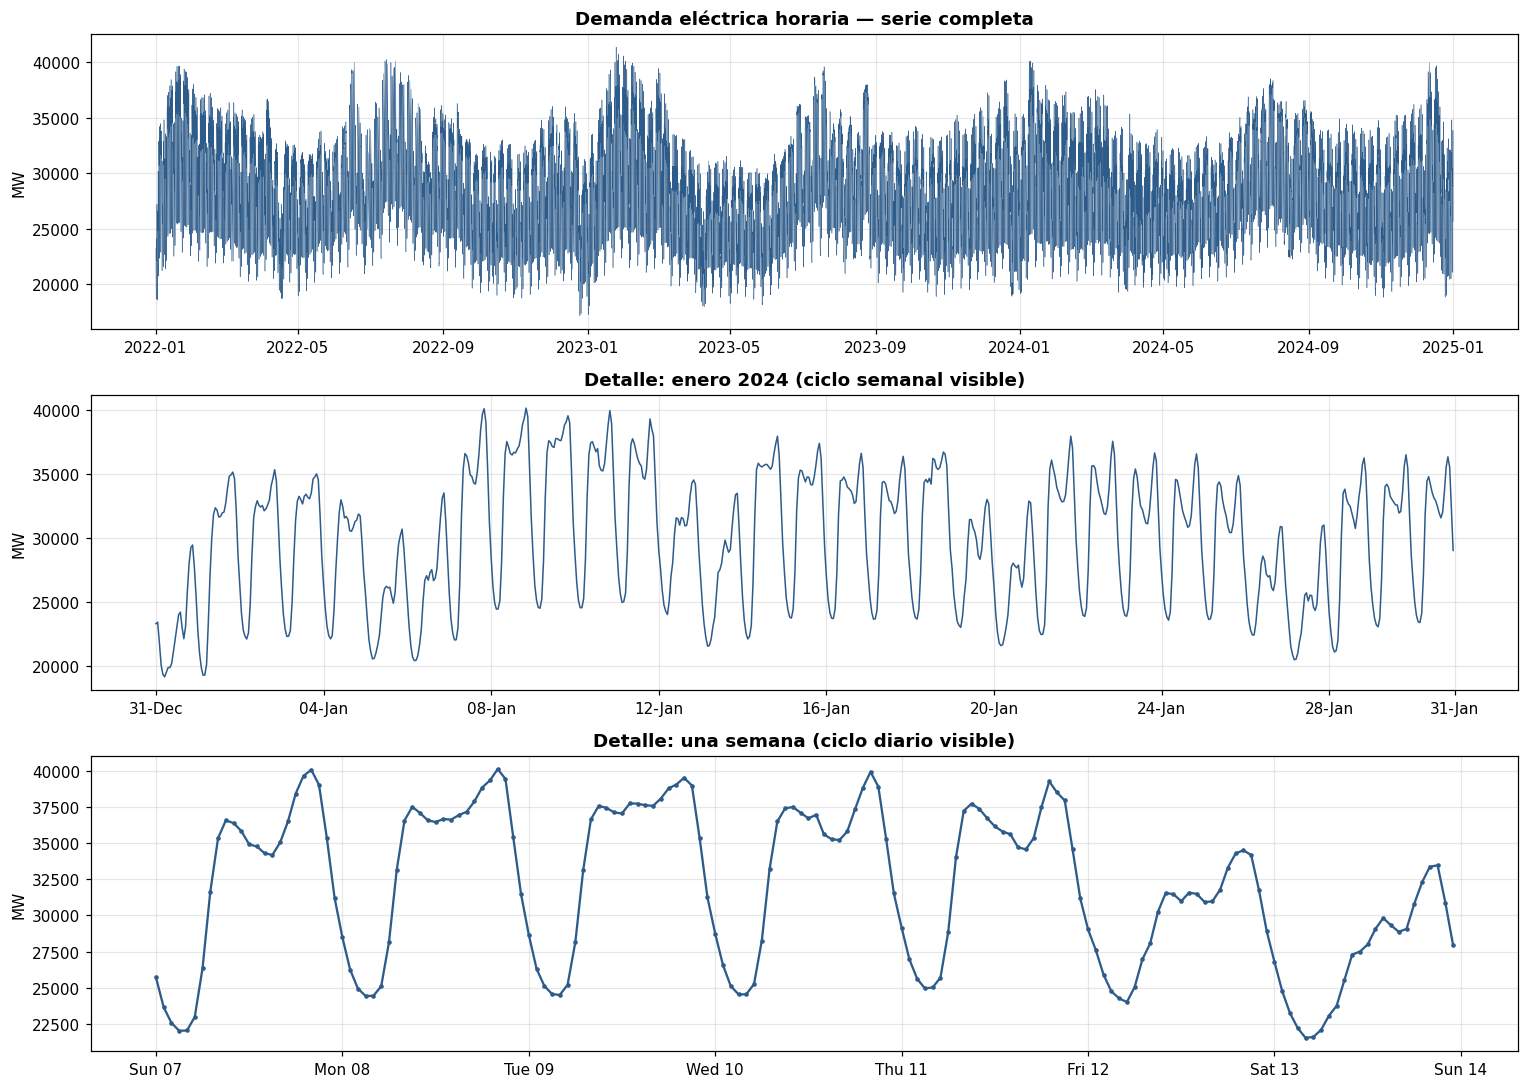

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Serie completa
axes[0].plot(df.index, df["demanda_mw"], lw=0.3, color="#2E5C8A")
axes[0].set_title("Demanda eléctrica horaria — serie completa", fontweight="bold")
axes[0].set_ylabel("MW")

# Un mes
mes = df.loc["2024-01"]
axes[1].plot(mes.index, mes["demanda_mw"], lw=1, color="#2E5C8A")
axes[1].set_title("Detalle: enero 2024 (ciclo semanal visible)", fontweight="bold")
axes[1].set_ylabel("MW")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))

# Una semana
sem = df.loc["2024-01-08":"2024-01-14"]
axes[2].plot(sem.index, sem["demanda_mw"], lw=1.5, marker="o", ms=2, color="#2E5C8A")
axes[2].set_title("Detalle: una semana (ciclo diario visible)", fontweight="bold")
axes[2].set_ylabel("MW")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))

plt.tight_layout()
guardar_figura("01_serie_temporal")
plt.show()

## 5.2 Reindexado y relleno de huecos  **[TUTOR]**

### Estrategia de relleno en tres niveles

1. **Huecos cortos (≤ 3 h)** → interpolación temporal. En un tramo tan corto la
   curva es casi lineal y el error es despreciable.
2. **Huecos largos** → valor de **la misma hora de la semana anterior**
   (desplazamiento de 168 h). Preserva el perfil diario y el efecto del día de
   la semana, cosa que la interpolación lineal destruiría al trazar una recta a
   través de varios ciclos completos.
3. **Resto** → mediana del perfil `mes × día de la semana × hora`.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# A.1 — Diagnóstico de huecos
# ═══════════════════════════════════════════════════════════════════════════
idx_completo = pd.date_range(df.index.min(), df.index.max(), freq="h")
ausentes = idx_completo.difference(df.index)

print(f"Timestamps esperados : {len(idx_completo):,}")
print(f"Timestamps presentes : {len(df):,}")
print(f"Timestamps ausentes  : {len(ausentes):,}")
print(f"Valores NaN          : {df['demanda_mw'].isna().sum():,}")

# ── Reindexar: los huecos pasan a ser NaN explícitos ─────────────────────
df = df.reindex(idx_completo)
df.index.name = "datetime"

print(f"\nTras reindexar -> {len(df):,} filas, "
      f"{df['demanda_mw'].isna().sum():,} NaN")

# ── Inventario de huecos consecutivos ────────────────────────────────────
es_nan = df["demanda_mw"].isna()

if es_nan.any():
    grupo = (es_nan != es_nan.shift()).cumsum()[es_nan]
    fechas_nan = df.index[es_nan].to_series()

    huecos = pd.DataFrame({
        "inicio": fechas_nan.groupby(grupo).first(),
        "fin":    fechas_nan.groupby(grupo).last(),
        "horas":  grupo.groupby(grupo).size(),
    }).reset_index(drop=True)
    huecos["dias"] = (huecos["horas"] / 24).round(2)

    print(f"\nHuecos detectados: {len(huecos)}")
    display(huecos)
else:
    huecos = pd.DataFrame()
    print("\nSin huecos.")

Timestamps esperados : 26,304
Timestamps presentes : 26,214
Timestamps ausentes  : 90
Valores NaN          : 0

Tras reindexar -> 26,304 filas, 90 NaN

Huecos detectados: 5


,inicio,fin,horas,dias
0,2022-03-06 03:00:00+01:00,2022-03-06 20:00:00+01:00,18,0.75
1,2022-06-29 03:00:00+02:00,2022-06-29 20:00:00+02:00,18,0.75
2,2022-12-19 03:00:00+01:00,2022-12-19 20:00:00+01:00,18,0.75
3,2023-04-12 03:00:00+02:00,2023-04-12 20:00:00+02:00,18,0.75
4,2023-10-03 03:00:00+02:00,2023-10-03 20:00:00+02:00,18,0.75


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# A.2 — Relleno escalonado
# ═══════════════════════════════════════════════════════════════════════════
UMBRAL_HUECO_CORTO = 3      # horas

serie_antes = df["demanda_mw"].copy()          # para la comparativa [TUTOR]
n_inicial   = serie_antes.isna().sum()

# ── Nivel 1: huecos cortos por interpolación temporal ────────────────────
df["demanda_mw"] = df["demanda_mw"].interpolate(
    method="time", limit=UMBRAL_HUECO_CORTO, limit_area="inside")
print(f"Nivel 1 (interpolación ≤{UMBRAL_HUECO_CORTO}h): "
      f"{n_inicial - df['demanda_mw'].isna().sum():,} valores rellenados")

# ── Nivel 2: misma hora de semanas adyacentes ────────────────────────────
for desplazamiento in [168, -168, 336, -336]:
    faltan = df["demanda_mw"].isna()
    if not faltan.any():
        break
    n_antes = faltan.sum()
    df.loc[faltan, "demanda_mw"] = df["demanda_mw"].shift(desplazamiento)[faltan]
    n_rellenados = n_antes - df["demanda_mw"].isna().sum()
    if n_rellenados:
        signo = "anterior" if desplazamiento > 0 else "siguiente"
        semanas = abs(desplazamiento) // 168
        print(f"Nivel 2 ({semanas} semana/s {signo}): {n_rellenados:,} valores")

# ── Nivel 3: perfil mediano mes x día de la semana x hora ────────────────
if df["demanda_mw"].isna().any():
    n_antes = df["demanda_mw"].isna().sum()
    perfil = (df.assign(_m=df.index.month, _d=df.index.dayofweek, _h=df.index.hour)
                .groupby(["_m", "_d", "_h"])["demanda_mw"].transform("median"))
    df["demanda_mw"] = df["demanda_mw"].fillna(perfil)
    print(f"Nivel 3 (perfil mediano): {n_antes - df['demanda_mw'].isna().sum():,} valores")

print(f"\nNaN restantes: {df['demanda_mw'].isna().sum()}")
assert df["demanda_mw"].isna().sum() == 0, "quedan huecos sin rellenar"

serie_despues = df["demanda_mw"]

Nivel 1 (interpolación ≤3h): 15 valores rellenados
Nivel 2 (1 semana/s anterior): 75 valores

NaN restantes: 0


Estadísticos descriptivos antes y después del relleno



,Antes,Después,Δ %
count,26214.00,26304.00,0.34
mean,28220.66,28222.54,0.01
std,4469.66,4468.04,-0.04
min,17165.00,17165.00,0.00
25%,24510.27,24515.83,0.02
50%,28321.08,28323.08,0.01
75%,31522.81,31526.50,0.01
max,41348.92,41348.92,0.00


  guardada -> figuras\03_interpolacion_antes_despues.png


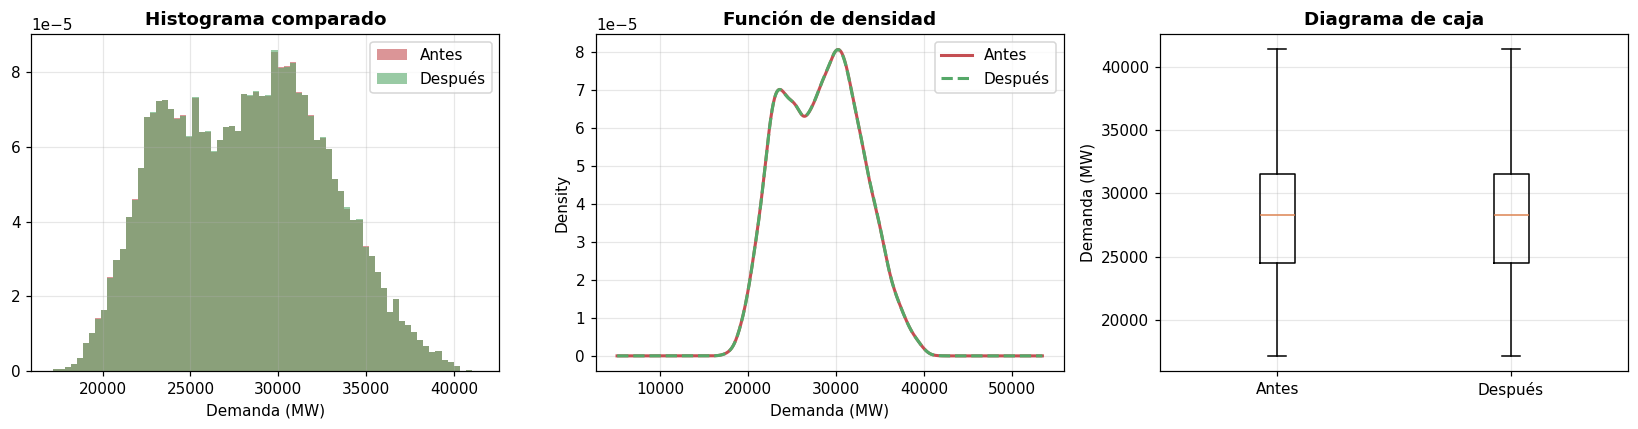


Valores rellenados : 90 (0.342% del total)
Test Kolmogorov-Smirnov: D=0.000357  p-valor=1.0000
  -> No se rechaza la hipótesis de misma distribución.
     El relleno no ha alterado la estructura estadística de la serie.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# A.3 — Verificación de la distribución  [TUTOR]
# ═══════════════════════════════════════════════════════════════════════════
comparativa = pd.DataFrame({
    "Antes":   serie_antes.describe(),
    "Después": serie_despues.describe(),
})
comparativa["Δ %"] = ((comparativa["Después"] - comparativa["Antes"])
                      / comparativa["Antes"] * 100).round(4)

print("Estadísticos descriptivos antes y después del relleno\n")
display(comparativa.round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(serie_antes.dropna(), bins=70, alpha=0.6,
             label="Antes", color="#C44E52", density=True)
axes[0].hist(serie_despues, bins=70, alpha=0.6,
             label="Después", color="#55A868", density=True)
axes[0].set_title("Histograma comparado", fontweight="bold")
axes[0].set_xlabel("Demanda (MW)"); axes[0].legend()

serie_antes.dropna().plot(kind="density", ax=axes[1],
                          label="Antes", color="#C44E52", lw=2)
serie_despues.plot(kind="density", ax=axes[1],
                   label="Después", color="#55A868", lw=2, ls="--")
axes[1].set_title("Función de densidad", fontweight="bold")
axes[1].set_xlabel("Demanda (MW)"); axes[1].legend()

axes[2].boxplot([serie_antes.dropna(), serie_despues],
                tick_labels=["Antes", "Después"])
axes[2].set_title("Diagrama de caja", fontweight="bold")
axes[2].set_ylabel("Demanda (MW)")

plt.tight_layout()
guardar_figura("03_interpolacion_antes_despues")
plt.show()

# Contraste estadístico
from scipy.stats import ks_2samp
ks = ks_2samp(serie_antes.dropna(), serie_despues)

n_rellenados = len(serie_despues) - serie_antes.notna().sum()
print(f"\nValores rellenados : {n_rellenados:,} "
      f"({n_rellenados/len(serie_despues)*100:.3f}% del total)")
print(f"Test Kolmogorov-Smirnov: D={ks.statistic:.6f}  p-valor={ks.pvalue:.4f}")

if ks.pvalue > 0.05:
    print("  -> No se rechaza la hipótesis de misma distribución.")
    print("     El relleno no ha alterado la estructura estadística de la serie.")
else:
    print("  -> ATENCIÓN: la distribución ha cambiado. Revisa la estrategia.")

  guardada -> figuras\03b_hueco_rellenado.png


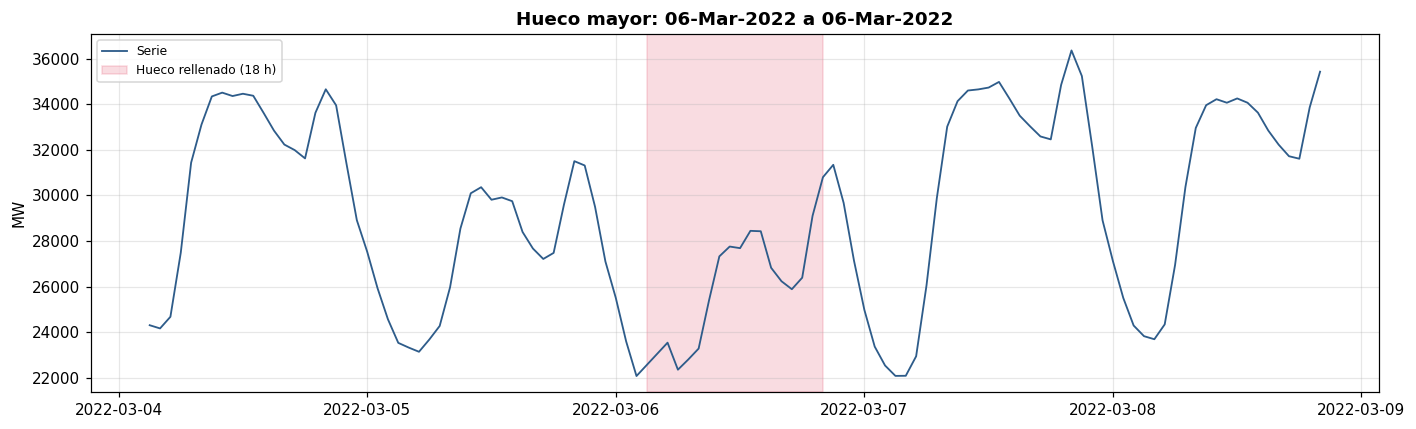

Comprueba que el tramo rellenado mantiene el perfil diario y no aparece como una recta.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# A.4 — Inspección visual del hueco más largo
# ═══════════════════════════════════════════════════════════════════════════
# Comprobación de que el relleno es plausible y respeta el perfil diario.

if len(huecos):
    mayor = huecos.loc[huecos["horas"].idxmax()]
    margen = pd.Timedelta(hours=48)
    tramo = df.loc[mayor["inicio"] - margen : mayor["fin"] + margen, "demanda_mw"]

    plt.figure(figsize=(13, 4))
    plt.plot(tramo.index, tramo.values, lw=1.2, color="#2E5C8A", label="Serie")
    plt.axvspan(mayor["inicio"], mayor["fin"], color="crimson", alpha=0.15,
                label=f"Hueco rellenado ({int(mayor['horas'])} h)")
    plt.title(f"Hueco mayor: {mayor['inicio']:%d-%b-%Y} a {mayor['fin']:%d-%b-%Y}",
              fontweight="bold")
    plt.ylabel("MW"); plt.legend(fontsize=8)
    plt.tight_layout()
    guardar_figura("03b_hueco_rellenado")
    plt.show()

    print("Comprueba que el tramo rellenado mantiene el perfil diario "
          "y no aparece como una recta.")

## 5.3 Reparación tras el reindexado

Recalcula todas las variables derivadas del índice y completa la meteorología.
Como los datos de AEMET son diarios, basta propagar el valor dentro del mismo
día natural.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# D.1 — Diagnóstico
# ═══════════════════════════════════════════════════════════════════════════
cols_revisar = [c for c in ["hora","dia_sem","mes","anio","festivo","finde",
                            "laborable","tmed","tmax","tmin"] if c in df.columns]

diagnostico = pd.DataFrame({
    "tipo":  df[cols_revisar].dtypes.astype(str),
    "NaN":   df[cols_revisar].isna().sum(),
})
print("Estado de las columnas tras el reindexado\n")
display(diagnostico)

if diagnostico["NaN"].sum() == 0:
    print("\nSin NaN: la reparación no es necesaria, pero ejecutarla no hace daño.")
else:
    print(f"\n{diagnostico['NaN'].sum():,} valores ausentes a reparar.")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# D.2 — Recalcular variables de calendario desde el índice
# ═══════════════════════════════════════════════════════════════════════════
# El índice siempre es correcto tras el reindexado, así que todas las
# variables de calendario se pueden regenerar desde él sin ambigüedad.

df["fecha"]     = df.index.normalize().tz_localize(None)
df["hora"]      = df.index.hour.astype("int16")
df["dia_sem"]   = df.index.dayofweek.astype("int8")      # 0 = lunes
df["dia_mes"]   = df.index.day.astype("int8")
df["mes"]       = df.index.month.astype("int8")
df["anio"]      = df.index.year.astype("int16")

df["festivo"]   = df["fecha"].isin(df_festivos["fecha"]).astype("int8")
df["finde"]     = (df["dia_sem"] >= 5).astype("int8")
df["laborable"] = ((df["finde"] == 0) & (df["festivo"] == 0)).astype("int8")

print("Variables de calendario recalculadas:")
print(df[["hora","dia_sem","mes","anio","festivo","finde","laborable"]]
        .dtypes.to_string())

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# D.3 — Completar variables meteorológicas
# ═══════════════════════════════════════════════════════════════════════════
# AEMET publica valores diarios. Para las horas nuevas basta propagar el valor
# del mismo día natural; si el día entero falta, se interpola entre días.

COLS_METEO = [c for c in ["tmed","tmax","tmin","prec","velmedia","racha",
                          "sol","presMax","presMin","hrMedia"] if c in df.columns]

if COLS_METEO:
    for col in COLS_METEO:
        n_antes = df[col].isna().sum()
        # dentro del mismo día
        df[col] = df.groupby("fecha")[col].transform(lambda s: s.ffill().bfill())
        # días completos ausentes
        df[col] = df[col].interpolate(method="time", limit_direction="both")
        n_despues = df[col].isna().sum()
        if n_antes:
            print(f"  {col:10} {n_antes:>4} -> {n_despues:>4} NaN")
    print("\nMeteorología completada.")
else:
    print("Sin columnas meteorológicas (¿aún no has ejecutado la sección 2?).")

# ── Verificación final ───────────────────────────────────────────────────
restantes = df[cols_revisar].isna().sum()
if restantes.sum() == 0:
    print("\nTodas las columnas completas. Puedes continuar con el EDA.")
else:
    print("\nQuedan NaN:")
    display(restantes[restantes > 0])

## 5.4 Análisis de Fourier  **[TUTOR]**

> *"Series de Fourier para identificar patrones."*

Descomponemos la señal en frecuencias mediante la Transformada Rápida de Fourier
(FFT) para identificar los periodos dominantes de forma objetiva, sin asumirlos
de antemano.

In [ ]:
serie = df["demanda_mw"].values
serie_centrada = serie - serie.mean()

# Transformada rápida de Fourier
fft_vals  = np.fft.rfft(serie_centrada)
frecs     = np.fft.rfftfreq(len(serie_centrada), d=1.0)   # d = 1 hora
potencia  = np.abs(fft_vals) ** 2

# Descartar la frecuencia cero
mask     = frecs > 0
periodos = 1 / frecs[mask]      # en horas
pot      = potencia[mask]

# Top periodos dominantes
top_idx = np.argsort(pot)[-15:][::-1]

tabla_fourier = pd.DataFrame({
    "Periodo (h)":     periodos[top_idx].round(1),
    "Periodo (días)":  (periodos[top_idx] / 24).round(2),
    "Potencia":        pot[top_idx],
}).reset_index(drop=True)

print("Periodos dominantes detectados por Fourier\n")
display(tabla_fourier.head(10))

Periodos dominantes detectados por Fourier



,Periodo (h),Periodo (días),Potencia
0,24.0,1.00,2.306755e+15
1,12.0,0.50,9.243786e+14
2,4384.0,182.67,8.246818e+14
3,167.5,6.98,4.905913e+14
4,168.6,7.03,2.825111e+14
5,84.0,3.50,2.631884e+14
6,26304.0,1096.00,6.030872e+13
7,1096.0,45.67,5.575491e+13
8,33.6,1.40,5.201271e+13
9,6.0,0.25,4.357633e+13


  guardada -> figuras\04_fourier_periodograma.png


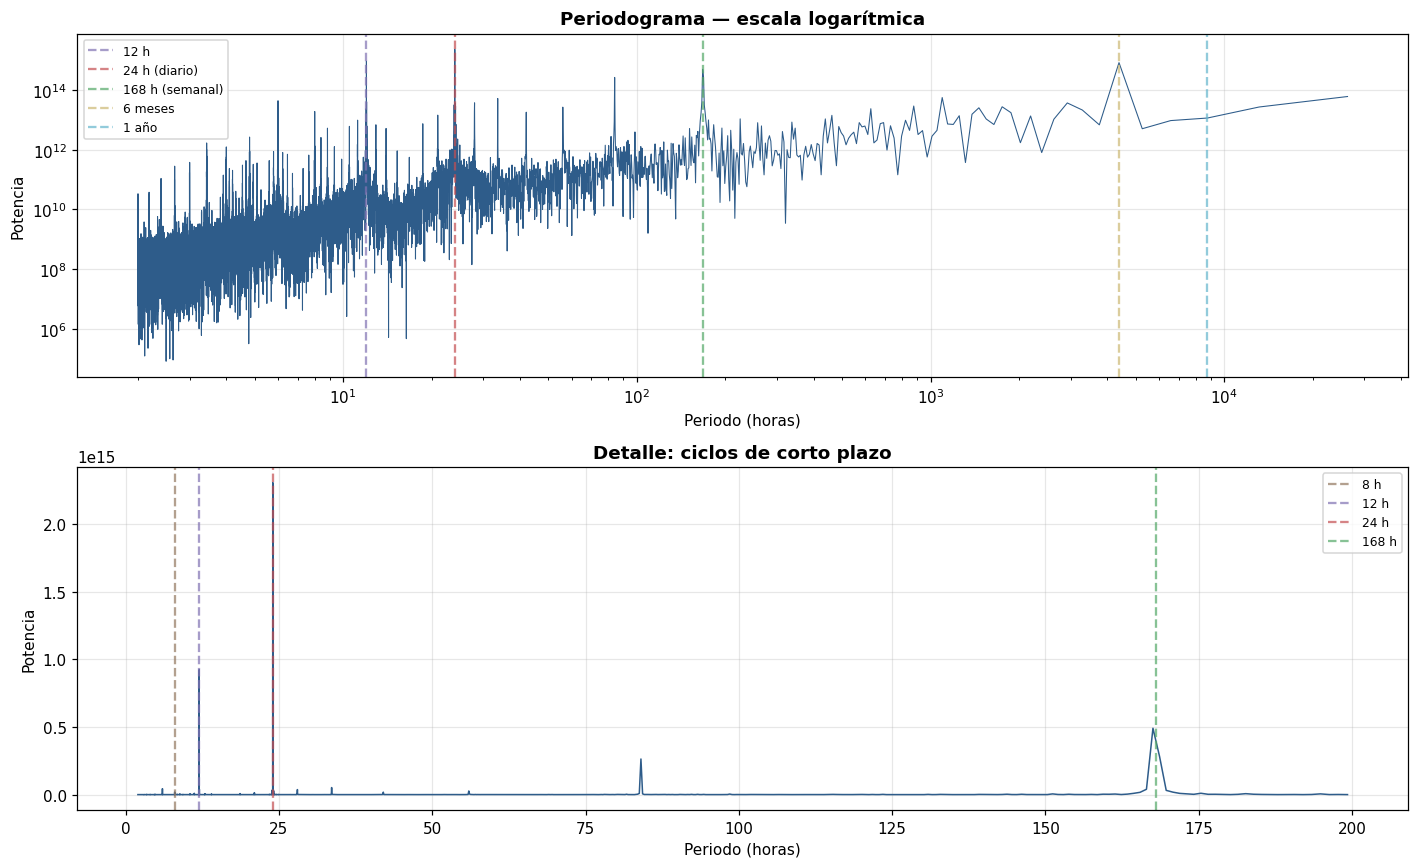

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Periodograma completo
axes[0].plot(periodos, pot, lw=0.7, color="#2E5C8A")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("Periodo (horas)"); axes[0].set_ylabel("Potencia")
axes[0].set_title("Periodograma — escala logarítmica", fontweight="bold")

for periodo, etiqueta, color in [(12, "12 h", "#8172B2"),
                                 (24, "24 h (diario)", "#C44E52"),
                                 (168, "168 h (semanal)", "#55A868"),
                                 (4383, "6 meses", "#CCB974"),
                                 (8766, "1 año", "#64B5CD")]:
    axes[0].axvline(periodo, ls="--", alpha=0.7, color=color, label=etiqueta)
axes[0].legend(fontsize=8, loc="upper left")

# Zoom en el rango 0–200 h
zoom = (periodos >= 2) & (periodos <= 200)
axes[1].plot(periodos[zoom], pot[zoom], lw=1, color="#2E5C8A")
axes[1].set_xlabel("Periodo (horas)"); axes[1].set_ylabel("Potencia")
axes[1].set_title("Detalle: ciclos de corto plazo", fontweight="bold")
for periodo, etiqueta, color in [(8, "8 h", "#937860"),
                                 (12, "12 h", "#8172B2"),
                                 (24, "24 h", "#C44E52"),
                                 (168, "168 h", "#55A868")]:
    axes[1].axvline(periodo, ls="--", alpha=0.7, color=color, label=etiqueta)
axes[1].legend(fontsize=8)

plt.tight_layout()
guardar_figura("04_fourier_periodograma")
plt.show()

### Interpretación

Los picos del periodograma confirman qué estacionalidades hay que modelar.
Típicamente aparecen:

- **24 h** — ciclo diario, el más intenso
- **12 h** — armónico del anterior (doble pico mañana/tarde)
- **168 h** — ciclo semanal, diferencia laborable/fin de semana
- **~8766 h** — ciclo anual, invierno/verano

Estos periodos justifican directamente las variables de la sección 6:
los *lags* de 24 h y 168 h y la codificación cíclica no son arbitrarios,
salen de aquí.

## 5.5 Descomposición estacional (MSTL)

La serie presenta **dos estacionalidades simultáneas**: diaria (24 h) y semanal
(168 h), ambas identificadas en el periodograma de la sección anterior.

Una descomposición `STL` con `period=24` solo captura la primera, de forma que
el ciclo semanal se acumula en el residuo y produce caídas sistemáticas
coincidentes con los fines de semana. `MSTL` admite varios periodos a la vez y
separa ambas componentes.

> **Sobre el arranque de la tendencia:** el tramo ascendente del extremo
> izquierdo del panel *Trend* es un artefacto de borde de la descomposición, no
> un fenómeno real. Conviene indicarlo en el pie de figura.

  guardada -> figuras\05_descomposicion_mstl.png


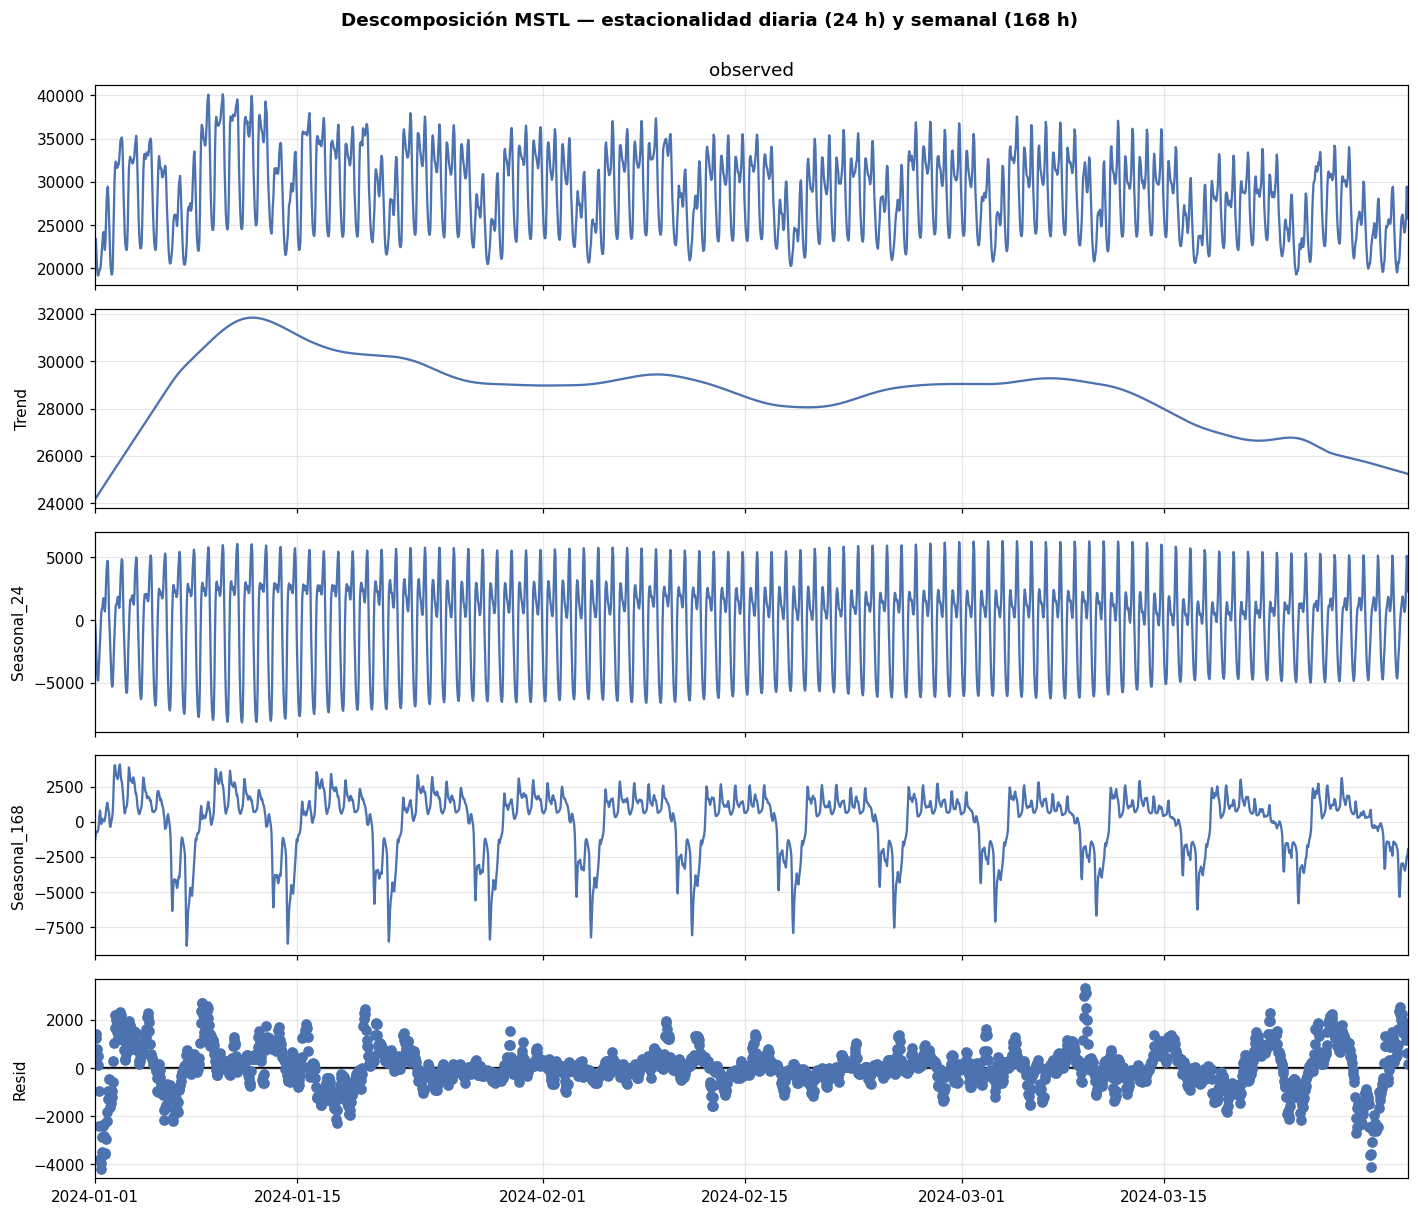

In [ ]:
from statsmodels.tsa.seasonal import MSTL, STL

# Ventana de análisis (3 meses da un gráfico legible)
ventana = df["demanda_mw"].loc["2024-01":"2024-03"]

# Estacionalidad diaria (24 h) + semanal (168 h)
mstl = MSTL(ventana, periods=(24, 168)).fit()

fig = mstl.plot()
fig.set_size_inches(13, 11)
fig.suptitle("Descomposición MSTL — estacionalidad diaria (24 h) y semanal (168 h)",
             fontweight="bold", y=1.00)
plt.tight_layout()
guardar_figura("05_descomposicion_mstl")
plt.show()

In [ ]:
# ── Fuerza de cada componente ────────────────────────────────────────────
# Métrica de Hyndman & Athanasopoulos (2021): 1 - Var(resid)/Var(comp + resid)
var_resid = mstl.resid.var()

fuerza_diaria  = max(0, 1 - var_resid / (mstl.seasonal["seasonal_24"]  + mstl.resid).var())
fuerza_semanal = max(0, 1 - var_resid / (mstl.seasonal["seasonal_168"] + mstl.resid).var())
fuerza_tend    = max(0, 1 - var_resid / (mstl.trend + mstl.resid).var())

print("Fuerza de las componentes (0 = inexistente, 1 = dominante)\n")
print(f"  Estacionalidad diaria (24 h)  : {fuerza_diaria:.4f}")
print(f"  Estacionalidad semanal (168 h): {fuerza_semanal:.4f}")
print(f"  Tendencia                     : {fuerza_tend:.4f}")

# ── Comparación con el STL simple del notebook original ──────────────────
stl_simple = STL(ventana, period=24, robust=True).fit()

mejora = (1 - mstl.resid.std() / stl_simple.resid.std()) * 100

print(f"\nDesviación típica del residuo")
print(f"  STL  (solo 24 h)      : {stl_simple.resid.std():>8.1f} MW")
print(f"  MSTL (24 h + 168 h)   : {mstl.resid.std():>8.1f} MW")
print(f"  Reducción             : {mejora:>8.1f} %")
print("\nLa reducción cuantifica cuánta señal semanal contaminaba el residuo.")

Fuerza de las componentes (0 = inexistente, 1 = dominante)

  Estacionalidad diaria (24 h)  : 0.9469
  Estacionalidad semanal (168 h): 0.8757
  Tendencia                     : 0.7815

Desviación típica del residuo
  STL  (solo 24 h)      :   1724.2 MW
  MSTL (24 h + 168 h)   :    841.9 MW
  Reducción             :     51.2 %

La reducción cuantifica cuánta señal semanal contaminaba el residuo.


  guardada -> figuras\05b_residuo_stl_vs_mstl.png


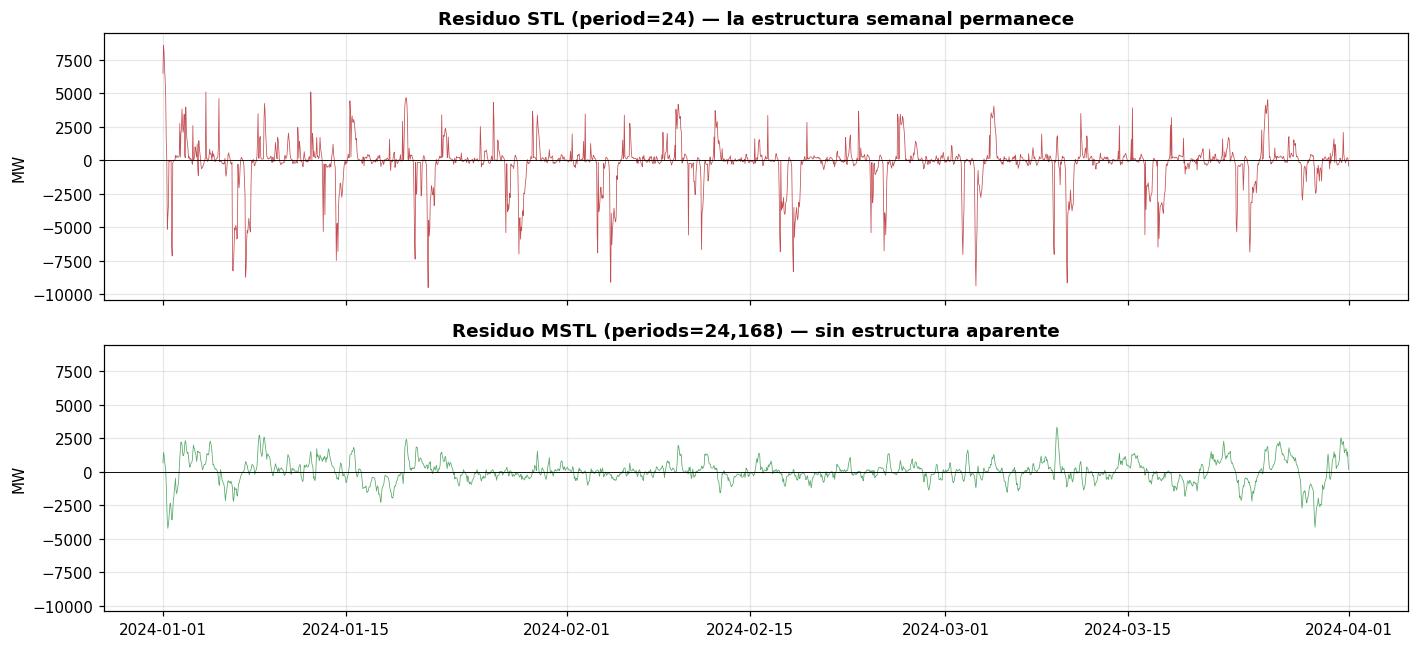

In [ ]:
# ── Evidencia visual: residuo de STL vs MSTL ─────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True, sharey=True)

axes[0].plot(stl_simple.resid.index, stl_simple.resid.values,
             lw=0.5, color="#C44E52")
axes[0].axhline(0, color="black", lw=0.6)
axes[0].set_title("Residuo STL (period=24) — la estructura semanal permanece",
                  fontweight="bold")
axes[0].set_ylabel("MW")

axes[1].plot(mstl.resid.index, mstl.resid.values, lw=0.5, color="#55A868")
axes[1].axhline(0, color="black", lw=0.6)
axes[1].set_title("Residuo MSTL (periods=24,168) — sin estructura aparente",
                  fontweight="bold")
axes[1].set_ylabel("MW")

plt.tight_layout()
guardar_figura("05b_residuo_stl_vs_mstl")
plt.show()

## 5.6 Autocorrelación (ACF / PACF)

Determinan los *lags* relevantes y orientan los órdenes de un modelo ARIMA.

  guardada -> figuras\06_acf_pacf.png


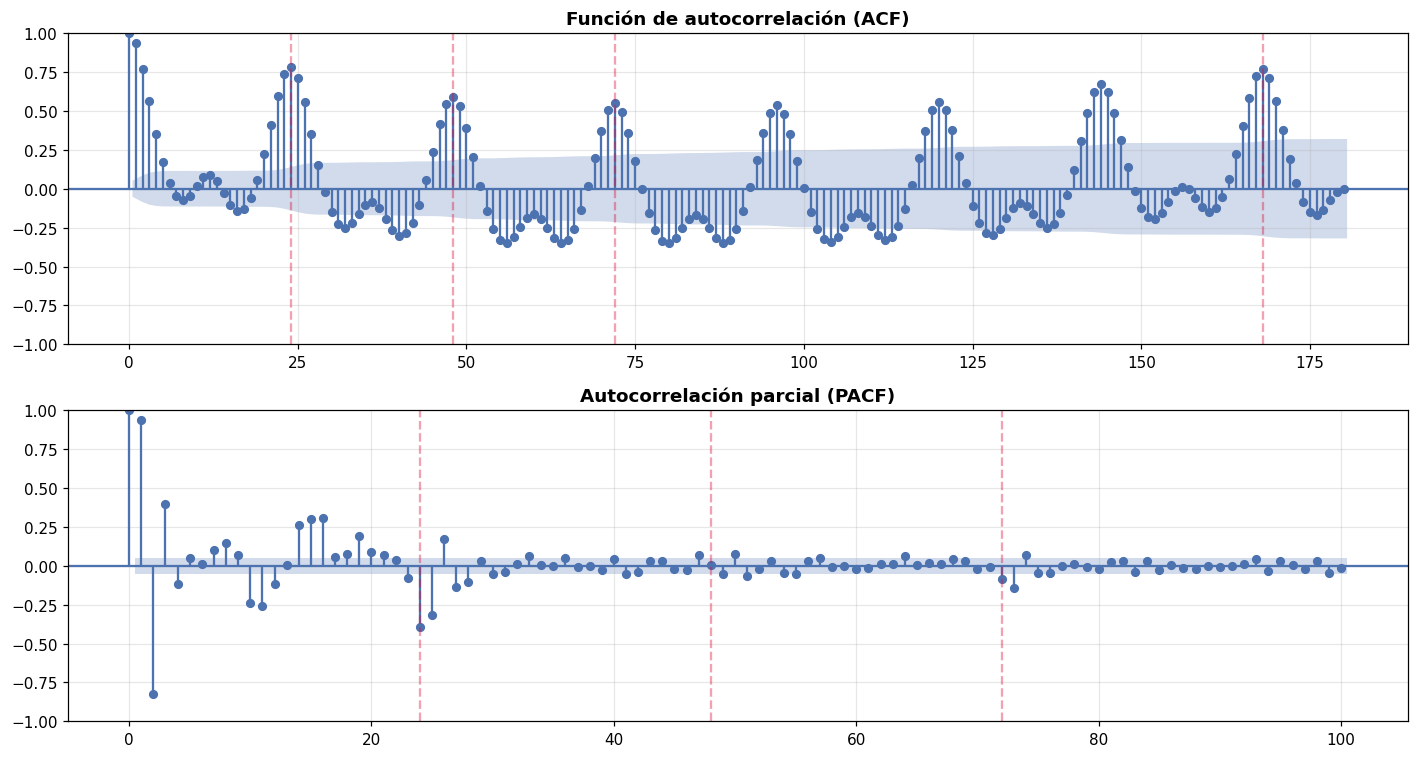

In [ ]:
muestra = df["demanda_mw"].loc["2024-01":"2024-02"]

fig, axes = plt.subplots(2, 1, figsize=(13, 7))

plot_acf(muestra, lags=180, ax=axes[0], alpha=0.05)
axes[0].set_title("Función de autocorrelación (ACF)", fontweight="bold")
for L in (24, 48, 72, 168):
    axes[0].axvline(L, color="crimson", ls="--", alpha=0.4)

plot_pacf(muestra, lags=100, ax=axes[1], alpha=0.05, method="ywm")
axes[1].set_title("Autocorrelación parcial (PACF)", fontweight="bold")
for L in (24, 48, 72):
    axes[1].axvline(L, color="crimson", ls="--", alpha=0.4)

plt.tight_layout()
guardar_figura("06_acf_pacf")
plt.show()

## 5.7 Estacionariedad (test de Dickey-Fuller aumentado)

In [ ]:
def test_estacionariedad(serie, nombre=""):
    r = adfuller(serie.dropna(), autolag="AIC")
    print(f"--- {nombre} ---")
    print(f"  Estadístico ADF : {r[0]:.4f}")
    print(f"  p-valor         : {r[1]:.6f}")
    print(f"  Valores críticos: " +
          ", ".join(f"{k}={v:.2f}" for k, v in r[4].items()))
    print(f"  -> {'ESTACIONARIA' if r[1] < 0.05 else 'NO estacionaria'}\n")
    return r[1] < 0.05

serie_test = df["demanda_mw"].loc["2024"]

test_estacionariedad(serie_test, "Serie original")
test_estacionariedad(serie_test.diff(), "Diferenciación de orden 1")
test_estacionariedad(serie_test.diff(24), "Diferenciación estacional (24 h)")

--- Serie original ---
  Estadístico ADF : -9.9098
  p-valor         : 0.000000
  Valores críticos: 1%=-3.43, 5%=-2.86, 10%=-2.57
  -> ESTACIONARIA

--- Diferenciación de orden 1 ---
  Estadístico ADF : -16.8098
  p-valor         : 0.000000
  Valores críticos: 1%=-3.43, 5%=-2.86, 10%=-2.57
  -> ESTACIONARIA

--- Diferenciación estacional (24 h) ---
  Estadístico ADF : -17.6486
  p-valor         : 0.000000
  Valores críticos: 1%=-3.43, 5%=-2.86, 10%=-2.57
  -> ESTACIONARIA



True

## 5.8 Perfiles de consumo

  guardada -> figuras\07_perfiles_consumo.png


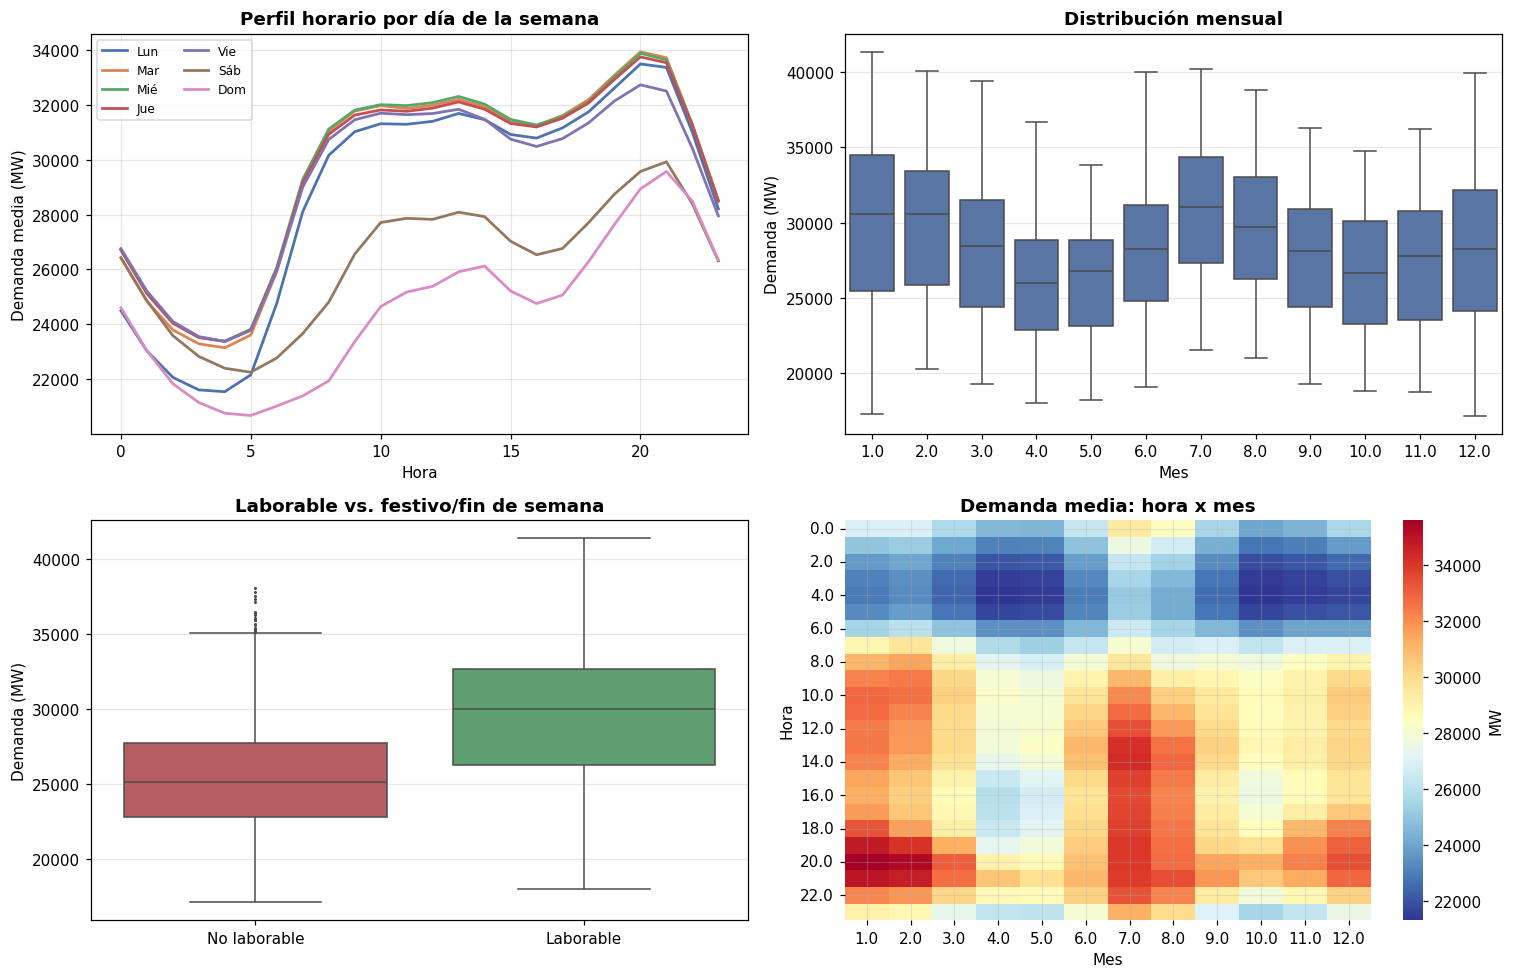

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Perfil horario por día de la semana
dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
perfil = df.pivot_table(index="hora", columns="dia_sem",
                        values="demanda_mw", aggfunc="mean")
perfil.columns = dias
perfil.plot(ax=axes[0, 0], lw=1.8)
axes[0, 0].set_title("Perfil horario por día de la semana", fontweight="bold")
axes[0, 0].set_xlabel("Hora"); axes[0, 0].set_ylabel("Demanda media (MW)")
axes[0, 0].legend(fontsize=8, ncol=2)

# Distribución por mes
sns.boxplot(data=df, x="mes", y="demanda_mw", ax=axes[0, 1],
            color="#4C72B0", fliersize=1)
axes[0, 1].set_title("Distribución mensual", fontweight="bold")
axes[0, 1].set_xlabel("Mes"); axes[0, 1].set_ylabel("Demanda (MW)")

# Laborable vs no laborable
sns.boxplot(data=df, x="laborable", y="demanda_mw", ax=axes[1, 0],
            palette=["#C44E52", "#55A868"], fliersize=1)
axes[1, 0].set_xticklabels(["No laborable", "Laborable"])
axes[1, 0].set_title("Laborable vs. festivo/fin de semana", fontweight="bold")
axes[1, 0].set_xlabel(""); axes[1, 0].set_ylabel("Demanda (MW)")

# Mapa de calor hora x mes
calor = df.pivot_table(index="hora", columns="mes",
                       values="demanda_mw", aggfunc="mean")
sns.heatmap(calor, cmap="RdYlBu_r", ax=axes[1, 1],
            cbar_kws={"label": "MW"})
axes[1, 1].set_title("Demanda media: hora x mes", fontweight="bold")
axes[1, 1].set_xlabel("Mes"); axes[1, 1].set_ylabel("Hora")

plt.tight_layout()
guardar_figura("07_perfiles_consumo")
plt.show()

## 5.9 Relación entre demanda y temperatura

Se espera una relación **en forma de U**: la demanda sube tanto con frío
(calefacción) como con calor (refrigeración).

  guardada -> figuras\08_demanda_temperatura.png


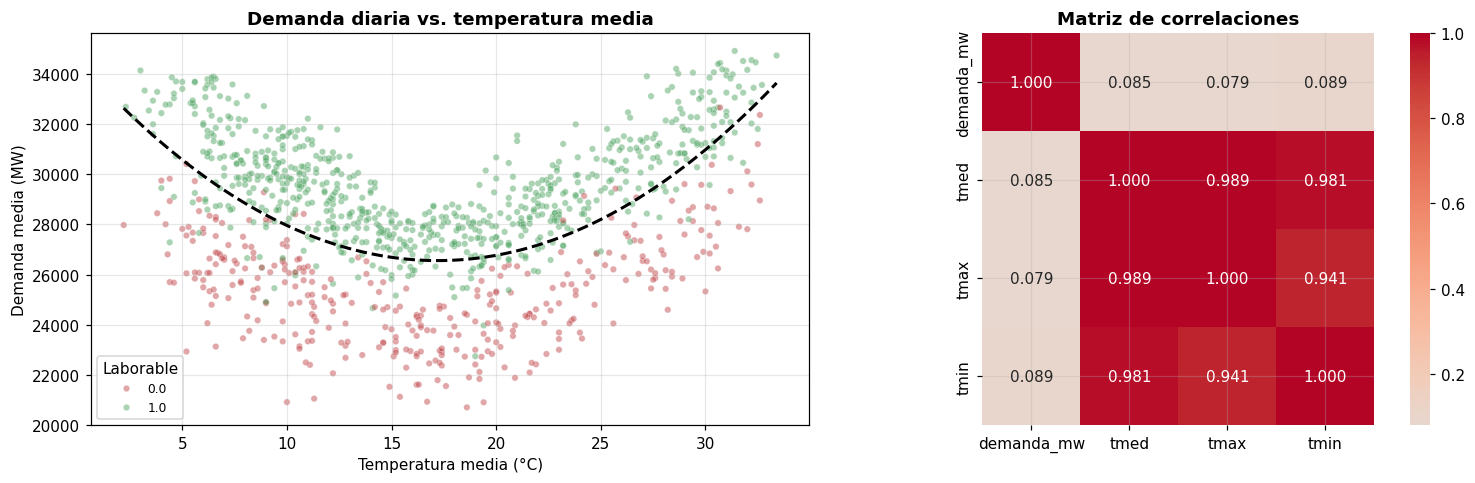

Correlación lineal demanda-tmed: 0.0847
(un valor bajo es esperable: la relación es cuadrática, no lineal)


In [ ]:
if "tmed" in df.columns and df["tmed"].notna().any():
    diario = df.resample("D").agg({"demanda_mw": "mean",
                                    "tmed": "first",
                                    "tmax": "first",
                                    "tmin": "first",
                                    "laborable": "first"}).dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    sns.scatterplot(data=diario, x="tmed", y="demanda_mw", hue="laborable",
                    alpha=0.5, s=18, ax=axes[0], palette=["#C44E52", "#55A868"])
    # Ajuste cuadrático para visualizar la U
    z = np.polyfit(diario["tmed"], diario["demanda_mw"], 2)
    xs = np.linspace(diario["tmed"].min(), diario["tmed"].max(), 100)
    axes[0].plot(xs, np.poly1d(z)(xs), color="black", lw=2, ls="--")
    axes[0].set_title("Demanda diaria vs. temperatura media", fontweight="bold")
    axes[0].set_xlabel("Temperatura media (°C)"); axes[0].set_ylabel("Demanda media (MW)")
    axes[0].legend(title="Laborable", fontsize=8)

    corr = diario[["demanda_mw", "tmed", "tmax", "tmin"]].corr()
    sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm",
                center=0, ax=axes[1], square=True)
    axes[1].set_title("Matriz de correlaciones", fontweight="bold")

    plt.tight_layout()
    guardar_figura("08_demanda_temperatura")
    plt.show()

    print(f"Correlación lineal demanda-tmed: {diario['demanda_mw'].corr(diario['tmed']):.4f}")
    print("(un valor bajo es esperable: la relación es cuadrática, no lineal)")
else:
    print("Sin datos meteorológicos. Ejecuta antes la sección 2.")

## 5.10 Valores atípicos

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# C.1 — Valor esperado y residuo
# ═══════════════════════════════════════════════════════════════════════════
UMBRAL_Z = 4.0     # |z| > 4 en escala robusta

# Las variables de calendario se regeneraron en la sección 5.3, de modo que
# aquí se dan por disponibles y con el tipo correcto.
assert not df[["mes", "dia_sem", "hora"]].isna().any().any(), \
    "Faltan variables de calendario: ejecuta antes la sección 5.3"

# Perfil esperado: mediana por mes x día de la semana x hora
df["esperado"] = (df.groupby(["mes", "dia_sem", "hora"])["demanda_mw"]
                    .transform("median"))
df["residuo"]  = df["demanda_mw"] - df["esperado"]

# z-score robusto (mediana y MAD)
mediana_res = df["residuo"].median()
mad = (df["residuo"] - mediana_res).abs().median()
df["z_robusto"] = 0.6745 * (df["residuo"] - mediana_res) / mad

df["atipico"] = (df["z_robusto"].abs() > UMBRAL_Z).astype(int)

n_atipicos = int(df["atipico"].sum())

print(f"MAD del residuo : {mad:,.1f} MW")
print(f"Umbral |z|      : {UMBRAL_Z}  (equivale a ±{UMBRAL_Z*mad/0.6745:,.0f} MW)")
print(f"Atípicos        : {n_atipicos:,} ({n_atipicos/len(df)*100:.2f}%)")

# Comparación con la regla IQR global
Q1, Q3 = df["demanda_mw"].quantile([0.25, 0.75])
IQR = Q3 - Q1
n_iqr = int(((df["demanda_mw"] < Q1 - 1.5*IQR) |
             (df["demanda_mw"] > Q3 + 1.5*IQR)).sum())
print(f"\nRegla IQR global habría detectado: {n_iqr:,}")
print(f"  (límites: {Q1-1.5*IQR:,.0f} — {Q3+1.5*IQR:,.0f} MW, "
      f"rango real: {df['demanda_mw'].min():,.0f} — {df['demanda_mw'].max():,.0f} MW)")

MAD del residuo : 819.5 MW
Umbral |z|      : 4.0  (equivale a ±4,860 MW)
Atípicos        : 556 (2.11%)

Regla IQR global habría detectado: 0
  (límites: 14,000 — 42,042 MW, rango real: 17,165 — 41,349 MW)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# C.2 — ¿Qué días son anómalos?
# ═══════════════════════════════════════════════════════════════════════════
if n_atipicos:
    resumen = (df[df["atipico"] == 1]
                 .assign(fecha=lambda d: d.index.date)
                 .groupby("fecha")
                 .agg(horas_atipicas=("atipico", "size"),
                      z_max=("z_robusto", lambda s: s.abs().max()),
                      desv_media=("residuo", "mean"))
                 .sort_values("horas_atipicas", ascending=False))

    resumen["signo"] = np.where(resumen["desv_media"] > 0,
                                "por encima", "por debajo")
    resumen["festivo"] = [int(pd.Timestamp(f) in df_festivos["fecha"].values)
                          for f in resumen.index]

    print(f"Días con horas anómalas: {len(resumen)}\n")
    display(resumen.head(15).round(2))
else:
    print("No se han detectado atípicos con este umbral.")
    print("Prueba a bajar UMBRAL_Z a 3.5 y volver a ejecutar.")

Días con horas anómalas: 72



,horas_atipicas,z_max,desv_media,signo,festivo
fecha,,,,,
2022-12-26,18,8.48,-8070.51,por debajo,1
2022-11-01,18,8.61,-7220.06,por debajo,1
2022-01-01,17,7.87,-6813.45,por debajo,1
2023-01-01,17,6.60,-6277.70,por debajo,0
2023-04-07,17,8.85,-7394.67,por debajo,1
2024-01-01,17,12.86,-10772.11,por debajo,1
2022-01-06,16,10.22,-8024.34,por debajo,1
2024-12-25,16,10.08,-8825.16,por debajo,1
2023-01-06,16,10.48,-9423.26,por debajo,1


  guardada -> figuras\09_atipicos_residuo.png


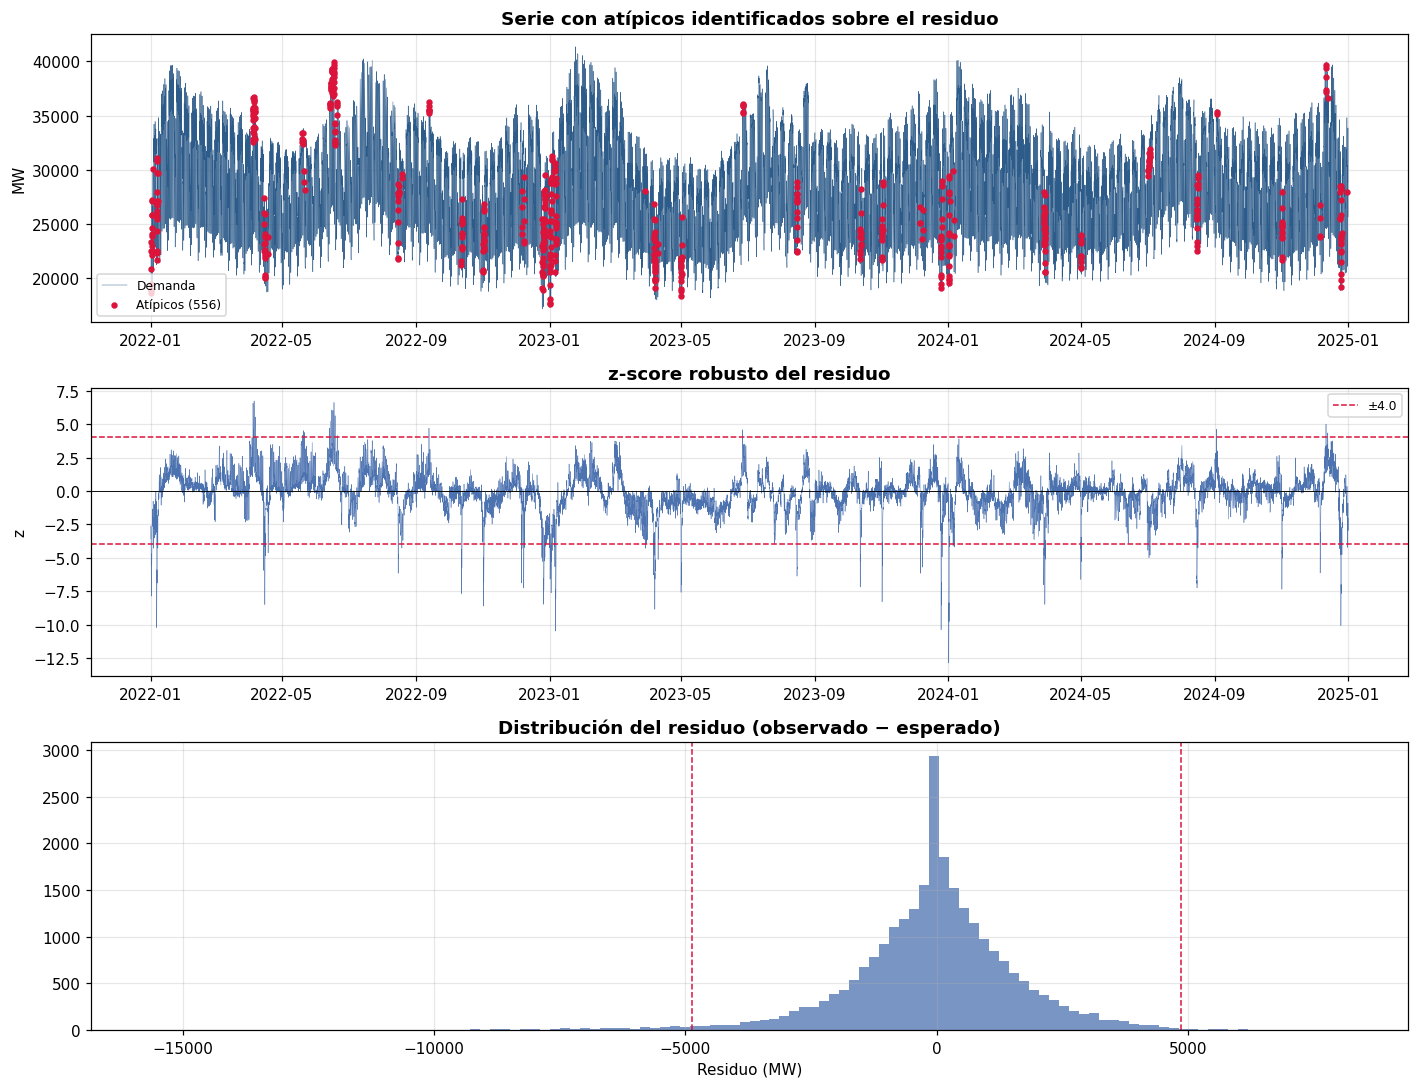

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# C.3 — Visualización
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(13, 10))

# Serie con atípicos marcados
axes[0].plot(df.index, df["demanda_mw"], lw=0.3, color="#2E5C8A", label="Demanda")
atip = df[df["atipico"] == 1]
axes[0].scatter(atip.index, atip["demanda_mw"], color="crimson", s=10,
                zorder=5, label=f"Atípicos ({n_atipicos})")
axes[0].set_title("Serie con atípicos identificados sobre el residuo",
                  fontweight="bold")
axes[0].set_ylabel("MW"); axes[0].legend(fontsize=8)

# z-score robusto
axes[1].plot(df.index, df["z_robusto"], lw=0.3, color="#4C72B0")
axes[1].axhline( UMBRAL_Z, color="crimson", ls="--", lw=1, label=f"±{UMBRAL_Z}")
axes[1].axhline(-UMBRAL_Z, color="crimson", ls="--", lw=1)
axes[1].axhline(0, color="black", lw=0.6)
axes[1].set_title("z-score robusto del residuo", fontweight="bold")
axes[1].set_ylabel("z"); axes[1].legend(fontsize=8)

# Distribución del residuo
axes[2].hist(df["residuo"], bins=120, color="#4C72B0", alpha=0.75)
lim = UMBRAL_Z * mad / 0.6745
axes[2].axvline( lim, color="crimson", ls="--", lw=1)
axes[2].axvline(-lim, color="crimson", ls="--", lw=1)
axes[2].set_title("Distribución del residuo (observado − esperado)",
                  fontweight="bold")
axes[2].set_xlabel("Residuo (MW)")

plt.tight_layout()
guardar_figura("09_atipicos_residuo")
plt.show()

> ### Criterio para la memoria
>
> **No elimines los atípicos automáticamente.** En demanda eléctrica, la mayoría
> de valores anómalos son reales: olas de calor, temporales, festivos con
> comportamiento inusual. Son precisamente los casos que el modelo debe aprender
> a predecir.
>
> Lo que sí debes hacer es **inspeccionarlos y documentarlos**: comprueba en
> hemeroteca o en registros de AEMET qué ocurrió esos días concretos. Si
> encuentras explicación meteorológica o de calendario, el atípico es legítimo y
> se conserva. Solo se plantea eliminar un valor cuando es físicamente imposible
> (demanda negativa, saltos instantáneos de varios miles de MW sin causa).
>
> Este análisis reaparecerá en el capítulo de resultados: los días con residuo
> alto suelen ser también aquellos donde el modelo final falla más.

---
## 5.11 Clasificación de las anomalías detectadas

La detección de la sección anterior produce un residuo marcadamente asimétrico:
la cola izquierda alcanza valores mucho mayores en magnitud que la derecha.

La causa es conocida y no constituye un error. El valor esperado se calcula
agrupando por `mes × día de la semana × hora`, agrupación que **no distingue los
días festivos**. Un 25 de diciembre se compara con el perfil medio de los
miércoles de diciembre, de modo que su consumo —sensiblemente menor— aparece
como una desviación de gran magnitud.

El resultado es informativo: cuantifica en qué medida los festivos se apartan
del patrón ordinario y **justifica empíricamente la inclusión de `festivo` y
variables asociadas** entre los predictores del modelo.

Esta sección separa las anomalías atribuibles al calendario de las que carecen
de explicación por esta vía. Estas últimas son las de mayor interés analítico:
olas de calor, temporales o incidencias de la red.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.11.1 — Etiquetar el origen de cada anomalía
# ═══════════════════════════════════════════════════════════════════════════
festivos_set = set(df_festivos["fecha"])

# Vísperas y días posteriores: el efecto del festivo se extiende a su entorno
df["vispera_festivo"] = (df["fecha"].add(pd.Timedelta(days=1))
                                    .isin(festivos_set).astype("int8"))
df["post_festivo"]    = (df["fecha"].sub(pd.Timedelta(days=1))
                                    .isin(festivos_set).astype("int8"))

condiciones = [
    df["festivo"] == 1,
    df["vispera_festivo"] == 1,
    df["post_festivo"] == 1,
    df["finde"] == 1,
]
etiquetas = [
    "Festivo",
    "Víspera de festivo",
    "Día posterior a festivo",
    "Fin de semana",
]
df["tipo_anomalia"] = np.select(condiciones, etiquetas,
                                default="Sin explicación de calendario")

atipicos = df[df["atipico"] == 1]

resumen = (atipicos.groupby("tipo_anomalia")
                   .agg(horas=("atipico", "size"),
                        residuo_medio=("residuo", "mean"),
                        z_max=("z_robusto", lambda s: s.abs().max()))
                   .sort_values("horas", ascending=False))
resumen["% del total"] = (resumen["horas"] / len(atipicos) * 100).round(1)

print(f"Anomalías detectadas: {len(atipicos):,} "
      f"({len(atipicos)/len(df)*100:.2f} % de la serie)\n")
display(resumen.round(1))

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.11.2 — Anomalías sin explicación de calendario
# ═══════════════════════════════════════════════════════════════════════════
# Candidatas a contrastar con registros meteorológicos o hemeroteca.

sin_explicar = atipicos[atipicos["tipo_anomalia"] == "Sin explicación de calendario"]

if len(sin_explicar):
    agregaciones = {
        "horas_anomalas": ("atipico", "size"),
        "residuo_medio":  ("residuo", "mean"),
        "z_max":          ("z_robusto", lambda s: s.abs().max()),
    }
    if "tmax" in df.columns:
        agregaciones["tmax"] = ("tmax", "first")
        agregaciones["tmin"] = ("tmin", "first")

    dias = (sin_explicar.assign(dia=lambda d: d.index.date)
                        .groupby("dia").agg(**agregaciones)
                        .sort_values("horas_anomalas", ascending=False))
    dias["sentido"] = np.where(dias["residuo_medio"] > 0,
                               "consumo superior", "consumo inferior")

    print(f"Días con anomalías no explicadas por el calendario: {len(dias)}\n")
    display(dias.head(20).round(1))

    print("\nLos días con consumo superior y temperatura extrema corresponden "
          "habitualmente a olas de calor o de frío.")
else:
    print("Todas las anomalías se explican por variables de calendario.")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.11.3 — Visualización por tipo de anomalía
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

colores = {
    "Festivo":                       "#C44E52",
    "Víspera de festivo":            "#DD8452",
    "Día posterior a festivo":       "#CCB974",
    "Fin de semana":                 "#8172B2",
    "Sin explicación de calendario": "#55A868",
}

# Serie con las anomalías coloreadas según su origen
axes[0].plot(df.index, df["demanda_mw"], lw=0.25, color="#BBBBBB", zorder=1)
for tipo, color in colores.items():
    sub = atipicos[atipicos["tipo_anomalia"] == tipo]
    if len(sub):
        axes[0].scatter(sub.index, sub["demanda_mw"], s=9, color=color,
                        label=f"{tipo} ({len(sub)})", zorder=5)
axes[0].set_title("Anomalías clasificadas por origen", fontweight="bold")
axes[0].set_ylabel("MW")
axes[0].legend(fontsize=7, ncol=2)

# Distribución del residuo según el tipo
orden = [t for t in colores if (atipicos["tipo_anomalia"] == t).any()]
datos = [atipicos.loc[atipicos["tipo_anomalia"] == t, "residuo"] for t in orden]
bp = axes[1].boxplot(datos, tick_labels=orden, patch_artist=True)
for parche, tipo in zip(bp["boxes"], orden):
    parche.set_facecolor(colores[tipo])
    parche.set_alpha(0.65)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Distribución del residuo según el origen de la anomalía",
                  fontweight="bold")
axes[1].set_ylabel("Residuo (MW)")
axes[1].tick_params(axis="x", labelsize=8, rotation=12)

plt.tight_layout()
guardar_figura("09b_atipicos_clasificados")
plt.show()

> ### Lectura para la memoria
>
> Si la mayor parte de las anomalías se concentra en festivos y vísperas, se
> dispone de un **argumento cuantitativo** —y no meramente intuitivo— para
> incorporar `festivo`, `vispera_festivo`, `post_festivo` y `laborable` como
> variables explicativas del modelo. Es el tipo de decisión razonada que debe
> quedar documentada en el capítulo de metodología.
>
> Los días sin explicación de calendario merecen contraste individual. Un día de
> julio con consumo muy superior al esperado y `tmax` por encima de 38 °C
> corresponde a una ola de calor; conviene documentarlo, porque esos mismos días
> reaparecerán en el análisis de errores del modelo final.

---
## 6. Ingeniería de características

Las variables se derivan directamente de lo observado en el EDA:
los *lags* elegidos son los periodos que identificó Fourier.

In [ ]:
dfm = df.copy()

# ── Lags (justificados por Fourier y ACF) ─────────────────────────────────
for lag in [1, 2, 3, 24, 25, 48, 168]:
    dfm[f"lag_{lag}h"] = dfm["demanda_mw"].shift(lag)

# ── Medias móviles ────────────────────────────────────────────────────────
for v in [24, 168]:
    dfm[f"media_{v}h"] = dfm["demanda_mw"].shift(1).rolling(v).mean()
    dfm[f"std_{v}h"]   = dfm["demanda_mw"].shift(1).rolling(v).std()

# ── Codificación cíclica ──────────────────────────────────────────────────
dfm["hora_sin"]    = np.sin(2 * np.pi * dfm["hora"] / 24)
dfm["hora_cos"]    = np.cos(2 * np.pi * dfm["hora"] / 24)
dfm["dia_sem_sin"] = np.sin(2 * np.pi * dfm["dia_sem"] / 7)
dfm["dia_sem_cos"] = np.cos(2 * np.pi * dfm["dia_sem"] / 7)
dfm["mes_sin"]     = np.sin(2 * np.pi * dfm["mes"] / 12)
dfm["mes_cos"]     = np.cos(2 * np.pi * dfm["mes"] / 12)

# ── Términos de temperatura (relación cuadrática) ─────────────────────────
if "tmed" in dfm.columns:
    dfm["tmed_sq"]    = dfm["tmed"] ** 2
    dfm["grados_frio"] = (18 - dfm["tmed"]).clip(lower=0)   # heating degree days
    dfm["grados_calor"] = (dfm["tmed"] - 22).clip(lower=0)  # cooling degree days

# Eliminar filas sin lag completo
dfm = dfm.dropna(subset=[f"lag_{l}h" for l in [1, 24, 168]])

print(f"Dataset final: {dfm.shape[0]:,} filas x {dfm.shape[1]} columnas")
print(f"\nVariables creadas:")
print([c for c in dfm.columns if c not in df.columns])

Dataset final: 26,136 filas x 43 columnas

Variables creadas:
['lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'lag_25h', 'lag_48h', 'lag_168h', 'media_24h', 'std_24h', 'media_168h', 'std_168h', 'hora_sin', 'hora_cos', 'dia_sem_sin', 'dia_sem_cos', 'mes_sin', 'mes_cos', 'tmed_sq', 'grados_frio', 'grados_calor']


---
## 7. Guardado del dataset

In [ ]:
RUTA_FINAL = DIR_DATOS / "dataset_modelado.parquet"
dfm.to_parquet(RUTA_FINAL)

print(f"Guardado en {RUTA_FINAL}")
print(f"  Filas   : {len(dfm):,}")
print(f"  Columnas: {dfm.shape[1]}")
print(f"  Periodo : {dfm.index.min()} a {dfm.index.max()}")
print(f"  Tamaño  : {RUTA_FINAL.stat().st_size / 1e6:.1f} MB")

print(f"\nFiguras generadas en {DIR_FIGURAS}/:")
for f in sorted(DIR_FIGURAS.glob("*.png")):
    print(f"  {f.name}")

Guardado en datos\dataset_modelado.parquet
  Filas   : 26,136
  Columnas: 43
  Periodo : 2022-01-08 00:00:00+01:00 a 2024-12-31 23:00:00+01:00
  Tamaño  : 3.0 MB

Figuras generadas en figuras/:
  01_serie_temporal.png
  03_interpolacion_antes_despues.png
  03b_hueco_rellenado.png
  04_fourier_periodograma.png
  05_descomposicion_mstl.png
  05_descomposicion_stl.png
  05b_residuo_stl_vs_mstl.png
  06_acf_pacf.png
  07_perfiles_consumo.png
  08_demanda_temperatura.png
  09_atipicos.png
  09_atipicos_residuo.png


---
## Siguientes pasos

1. **Revisar cada figura** y redactar en la memoria qué muestra y qué implica.
2. **Justificar la estrategia de relleno** con la comparativa de la sección 5.2
   y la inspección visual del hueco mayor.
3. **Documentar los periodos de Fourier** (sección 5.4): justifican los *lags*
   de 24 h y 168 h elegidos en la sección 6.
4. **Contrastar las anomalías sin explicación de calendario** (sección 5.11)
   con registros meteorológicos o hemeroteca.
5. Pasar al notebook `02_modelado.ipynb`: baseline ARIMA / SARIMA / Prophet.

### Checklist de requisitos del tutor

- [x] Tratamiento de datos documentado y verificado estadísticamente
- [x] Gráficas antes/después del relleno de huecos
- [x] Series de Fourier para identificar patrones
- [x] 2–3 años de datos (2022–2024)
- [x] Calendario laboral de Madrid
- [ ] Métricas de entrenamiento y producción → notebook 02
- [ ] Empezar por modelo sencillo e ir mejorándolo → notebook 02
- [ ] Diagrama de arquitectura → hacer aparte (draw.io / Excalidraw)

### Figuras generadas

| Archivo | Sección | Uso en la memoria |
|---|---|---|
| `01_serie_temporal` | 5.1 | Presentación de la serie |
| `03_interpolacion_antes_despues` | 5.2 | **Requisito del tutor** |
| `03b_hueco_rellenado` | 5.2 | Evidencia de relleno correcto |
| `04_fourier_periodograma` | 5.4 | **Requisito del tutor**. Justifica los *lags* |
| `05_descomposicion_mstl` | 5.5 | Estacionalidad múltiple |
| `05b_residuo_stl_vs_mstl` | 5.5 | Justifica el uso de MSTL |
| `06_acf_pacf` | 5.6 | Órdenes candidatos para ARIMA |
| `07_perfiles_consumo` | 5.8 | Patrones de consumo |
| `08_demanda_temperatura` | 5.9 | Relación no lineal con la temperatura |
| `09_atipicos_residuo` | 5.10 | Detección de anomalías |
| `09b_atipicos_clasificados` | 5.11 | Justifica las variables de calendario |